# 1.Setup Library

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import json

from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

#2.Setup Gdrive

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
path_folder = "/content/drive/MyDrive/Dataset GPT 4/"

# 3.Load Dataset

In [10]:
sick      = pd.read_csv('/content/drive/MyDrive/Dataset GPT 4/sick.csv')
insurance = pd.read_csv('/content/drive/MyDrive/Dataset GPT 4/insurance.csv')
diabetic  = pd.read_csv('/content/drive/MyDrive/Dataset GPT 4/diabetic_data.csv')

#4.Pengecekan Struktur Data

In [ ]:
print("=== INSURANCE ===")
display(insurance.head())

print("=== DIABETIC ===")
display(diabetic.head())

print("=== SICK ===")
display(sick.head())

=== INSURANCE ===


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


=== DIABETIC ===


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


=== SICK ===


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,TBG,referral_source,Class
0,41.0,F,f,f,f,f,f,f,f,f,...,t,125.0,t,1.14,t,109.0,f,NaN,SVHC,negative
1,23.0,F,f,f,f,f,f,f,f,f,...,t,102.0,f,NaN,f,NaN,f,NaN,other,negative
2,46.0,M,f,f,f,f,f,f,f,f,...,t,109.0,t,0.91,t,120.0,f,NaN,other,negative
3,70.0,F,t,f,f,f,f,f,f,f,...,t,175.0,f,NaN,f,NaN,f,NaN,other,negative
4,70.0,F,f,f,f,f,f,f,f,f,...,t,61.0,t,0.87,t,70.0,f,NaN,SVI,negative


In [ ]:
print("=== INSURANCE ===")
display(insurance.describe())

print("=== DIABETIC ===")
display(diabetic.describe())

print("=== SICK ===")
display(sick.describe())

=== INSURANCE ===


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


=== DIABETIC ===


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


=== SICK ===


,age,TSH,T3,TT4,T4U,FTI,TBG
count,3771.000000,3403.000000,3003.000000,3541.000000,3385.000000,3387.000000,0.0
mean,51.735879,5.086766,2.013500,108.319345,0.995000,110.469649,NaN
std,20.084958,24.521470,0.827434,35.604248,0.195457,33.089698,NaN
min,1.000000,0.005000,0.050000,2.000000,0.250000,2.000000,NaN
25%,36.000000,0.500000,1.600000,88.000000,0.880000,93.000000,NaN
50%,54.000000,1.400000,2.000000,103.000000,0.980000,107.000000,NaN
75%,67.000000,2.700000,2.400000,124.000000,1.080000,124.000000,NaN
max,455.000000,530.000000,10.600000,430.000000,2.320000,395.000000,NaN


# 5.Analisis Statistik Awal

In [ ]:
datasets = {
    "INSURANCE": {
        "df": insurance,
        "categorical": ['sex', 'children', 'smoker', 'region']
    },
    "SICK": {
        "df": sick,
        "categorical": ['sex', 'sick', 'on_thyroxine', 'query_on_thyroxine',
                        'on_antithyroid_medication', 'pregnant', 'thyroid_surgery',
                        'I131_treatment', 'query_hypothyroid', 'query_hyperthyroid',
                        'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych',
                        'TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured',
                        'FTI_measured', 'TBG_measured', 'Class']
    },
    "DIABETIC": {
        "df": diabetic,
        "categorical": ['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3',
                        'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
                        'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
                        'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
                        'miglitol', 'troglitazone', 'tolazamide', 'examide',
                        'citoglipton', 'insulin', 'glyburide-metformin',
                        'glipizide-metformin', 'glimepiride-pioglitazone',
                        'metformin-rosiglitazone', 'metformin-pioglitazone',
                        'change', 'diabetesMed', 'readmitted']
    }
}

for nama_dataset, config in datasets.items():
    df        = config["df"]
    cat_cols  = config["categorical"]

    print(f"\n{'='*60}")
    print(f"  DISTRIBUSI DATASET {nama_dataset}")
    print(f"  Total Observasi: {len(df):,}")
    print(f"{'='*60}")

    for col in cat_cols:
        if col not in df.columns:
            print(f"\n[!] Kolom '{col}' tidak ditemukan, dilewati.\n")
            continue

        # Ganti '?' dan NaN dengan 'Missing'
        data_col = df[col].replace('?', 'Missing').fillna('Missing')

        df_dist = pd.DataFrame({
            'Kategori'      : data_col.value_counts().index,
            'Jumlah'        : data_col.value_counts().values,
            'Persentase (%)': data_col.value_counts(normalize=True).mul(100).round(2).values
        }).sort_values('Kategori').reset_index(drop=True)

        print(f"\n  {col.upper()}")
        display(df_dist)
        print("-" * 60)


  DISTRIBUSI DATASET INSURANCE
  Total Observasi: 1,338

  SEX


,Kategori,Jumlah,Persentase (%)
0,female,662,49.48
1,male,676,50.52


------------------------------------------------------------

  CHILDREN


,Kategori,Jumlah,Persentase (%)
0,0,574,42.90
1,1,324,24.22
2,2,240,17.94
3,3,157,11.73
4,4,25,1.87
5,5,18,1.35


------------------------------------------------------------

  SMOKER


...

------------------------------------------------------------

  DIABETESMED


,Kategori,Jumlah,Persentase (%)
0,No,23403,23.0
1,Yes,78363,77.0


------------------------------------------------------------

  READMITTED


,Kategori,Jumlah,Persentase (%)
0,<30,11357,11.16
1,>30,35545,34.93
2,NO,54864,53.91


------------------------------------------------------------


# 6.Pengecekan Missing value dan Penanganan

| % Missing   | Keputusan                                              |
|-------------|--------------------------------------------------------|
| < 5%        | Drop baris atau Imputasi (keduanya aman)           |
| 5% – 30%    | Imputasi Median / Modus → zona aman             |
| 30% – 50%   | Imputasi masih boleh, tapi pertimbangkan dampaknya  |
| > 50%       | Drop kolom → data sudah tidak representatif         |



| Kondisi                          | Metode                              |
|----------------------------------|-------------------------------------|
| Kolom numerik (kontinu)      | Median → tahan terhadap outlier |
| Kolom kategorikal            | Modus → isi nilai terbanyak     |

In [ ]:
MISSING_VALUES = ['?', 'N/A', 'NA', 'nan', 'None', 'NULL', 'null', '-', '', ' ', 'Unknown/Invalid', 'missing']
datasets = {
    "sick"     : sick,
    "insurance": insurance,
    "diabetic" : diabetic,
}

for nama, df in datasets.items():
    # Ganti semua indikator missing → NaN
    df = df.replace(MISSING_VALUES, pd.NA)
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    print(f"\n{'='*50}")
    print(f"Dataset : {nama}  ({df.shape[0]} baris, {df.shape[1]} kolom)")
    print(f"Total missing: {df.isnull().sum().sum()}")
    print(f"{'='*50}")

    if missing.empty:
        print("✅ Tidak ada missing value!")
    else:
        result = pd.DataFrame({
            'Missing' : missing,
            'Persen %': (missing / len(df) * 100).round(2)
        })
        print(result.sort_values('Persen %', ascending=False).to_string())


Dataset : sick  (3772 baris, 30 kolom)
Total missing: 6064
     Missing  Persen %
TBG     3772    100.00
T3       769     20.39
T4U      387     10.26
FTI      385     10.21
TSH      369      9.78
TT4      231      6.12
sex      150      3.98
age        1      0.03

Dataset : insurance  (1338 baris, 7 kolom)
Total missing: 0
✅ Tidak ada missing value!

Dataset : diabetic  (101766 baris, 50 kolom)
Total missing: 374020
                   Missing  Persen %
weight               98569     96.86
max_glu_serum        96420     94.75
A1Cresult            84748     83.28
medical_specialty    49949     49.08
payer_code           40256     39.56
race                  2273      2.23
diag_3                1423      1.40
diag_2                 358      0.35
diag_1                  21      0.02
gender                   3      0.00


## 6.1 penanganan drop kolom untuk > 50% missing value(TBG,weight,max_glu_serum,A1Cresult)

In [ ]:
sick     = sick.drop(columns=['TBG'])
diabetic = diabetic.drop(columns=['weight', 'max_glu_serum', 'A1Cresult'])
print("Kolom sick setelah drop:", sick.shape)
print("Kolom diabetic setelah drop:", diabetic.shape)

Kolom sick setelah drop: (3772, 29)
Kolom diabetic setelah drop: (101766, 47)


##6.2 penanganan imputasi median untuk numerikal missing value(T3,T4U,FTI,TSH,TT4,age)

In [ ]:
kolom_median_sick = ['T3', 'T4U', 'FTI', 'TSH', 'TT4', 'age']

for col in kolom_median_sick:
    median_val = sick[col].median()
    sick[col]  = sick[col].fillna(median_val)
    print(f"[SICK] {col} → diimputasi dengan median: {median_val}")

print(f"\nMissing SICK setelah imputasi median:\n{sick[kolom_median_sick].isnull().sum()}")

[SICK] T3 → diimputasi dengan median: 2.0
[SICK] T4U → diimputasi dengan median: 0.98
[SICK] FTI → diimputasi dengan median: 107.0
[SICK] TSH → diimputasi dengan median: 1.4
[SICK] TT4 → diimputasi dengan median: 103.0
[SICK] age → diimputasi dengan median: 54.0

Missing SICK setelah imputasi median:
T3     0
T4U    0
FTI    0
TSH    0
TT4    0
age    0
dtype: int64


##6.3 Penanganan imputasi mode untuk kategorikal missing value(race,medical_speciality,payer_code,sex)

In [ ]:
diabetic['race'] = diabetic['race'].replace('?', np.nan)
diabetic['race'] = diabetic['race'].fillna(diabetic['race'].mode()[0])

print(f"Nilai race : {diabetic['race'].unique()}")
print(f"Missing    : {diabetic['race'].isnull().sum()}")

Nilai race : ['Caucasian' 'AfricanAmerican' 'Other' 'Asian' 'Hispanic']
Missing    : 0


In [ ]:
diabetic = diabetic.drop(columns=['payer_code', 'medical_specialty'])

print(f"Fitur tersisa diabetic : {diabetic.shape[1]} kolom")
print(f"payer_code ada        : {'payer_code' in diabetic.columns}")
print(f"medical_specialty ada : {'medical_specialty' in diabetic.columns}")

Fitur tersisa diabetic : 45 kolom
payer_code ada        : False
medical_specialty ada : False


In [ ]:
kolom_target = ['payer_code', 'medical_specialty']

for col in kolom_target:
    if col in diabetic.columns:
        print(f"⚠️  {col} masih ada → perlu di-drop")
    else:
        print(f"✅  {col} sudah tidak ada (sudah di-drop)")

✅  payer_code sudah tidak ada (sudah di-drop)
✅  medical_specialty sudah tidak ada (sudah di-drop)


In [ ]:
sick['sex'] = sick['sex'].fillna(sick['sex'].mode()[0])
print(f"sex      : {sick['sex'].isnull().sum()} missing")

sex      : 0 missing


##6.4 Penanganan Imputasi mode untuk missing value (gender,diag_1,diag_2,diag_3,)

In [ ]:
diabetic['gender'] = diabetic['gender'].replace('Unknown/Invalid', np.nan).fillna(diabetic['gender'].mode()[0])
print(f"gender   : {diabetic['gender'].isnull().sum()} missing")

gender   : 0 missing


In [ ]:
for col in ['diag_1', 'diag_2', 'diag_3']:
    diabetic[col] = diabetic[col].replace('?', np.nan).fillna(diabetic[col].mode()[0])
    print(f"{col:7} : {diabetic[col].isnull().sum()} missing")

diag_1  : 0 missing
diag_2  : 0 missing
diag_3  : 0 missing


# 7.Pengecekan duplikat data & Penghapusan duplikat

In [ ]:
datasets = {
    "sick"     : sick,
    "insurance": insurance,
    "diabetic" : diabetic,
}

for nama, df in datasets.items():
    total_dup = df.duplicated().sum()
    persen    = total_dup / len(df) * 100
    print(f"\n{'='*45}")
    print(f"Dataset : {nama}  ({len(df)} baris, {df.shape[1]} kolom)")
    print(f"{'='*45}")
    if total_dup == 0:
        print("✅ Tidak ada duplikat!")
    else:
        print(f"❌ Duplikat ditemukan : {total_dup} baris ({persen:.2f}%)")
        print(f"   Baris unik         : {len(df) - total_dup}")
        print(f"\n   Contoh baris duplikat:")
        display(df[df.duplicated()].head(3))


Dataset : sick  (3772 baris, 29 kolom)
❌ Duplikat ditemukan : 63 baris (1.67%)
   Baris unik         : 3709

   Contoh baris duplikat:


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,TBG_measured,referral_source,Class
204,26.0,F,f,f,f,f,f,f,f,f,...,2.0,f,103.0,f,0.98,f,107.0,f,other,negative
210,64.0,F,f,f,f,f,f,f,f,f,...,2.0,f,103.0,f,0.98,f,107.0,f,other,negative
303,22.0,F,f,f,f,f,f,f,f,f,...,2.0,f,103.0,f,0.98,f,107.0,f,other,negative



Dataset : insurance  (1338 baris, 7 kolom)
❌ Duplikat ditemukan : 1 baris (0.07%)
   Baris unik         : 1337

   Contoh baris duplikat:


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631



Dataset : diabetic  (101766 baris, 45 kolom)
✅ Tidak ada duplikat!


In [ ]:
sick      = sick.drop_duplicates().reset_index(drop=True)
insurance = insurance.drop_duplicates().reset_index(drop=True)

for nama, df in {"sick": sick, "insurance": insurance, "diabetic": diabetic}.items():
    print(f"{nama:10} : {df.duplicated().sum()} duplikat tersisa | {len(df)} baris")

sick       : 0 duplikat tersisa | 3709 baris
insurance  : 0 duplikat tersisa | 1337 baris
diabetic   : 0 duplikat tersisa | 101766 baris


# 8.Pengecekan dan Penanganan Nilai Outlier

In [ ]:
def cek_outlier(df, nama):
    kolom_numerik = df.select_dtypes(include='number').columns

    print(f"\n{'='*50}")
    print(f"Dataset : {nama}  ({len(df)} baris)")
    print(f"{'='*50}")

    total_outlier = 0
    for col in kolom_numerik:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1

        batas_bawah = Q1 - 1.5 * IQR
        batas_atas  = Q3 + 1.5 * IQR

        outlier = df[(df[col] < batas_bawah) | (df[col] > batas_atas)]
        jumlah  = len(outlier)
        persen  = jumlah / len(df) * 100
        total_outlier += jumlah

        if jumlah > 0:
            print(f"  {col:<30} : {jumlah:>5} outlier ({persen:.2f}%)")
            print(f"  {'':30}   batas bawah={batas_bawah:.2f}, batas atas={batas_atas:.2f}")

    if total_outlier == 0:
        print("✅ Tidak ada outlier!")
    else:
        print(f"\n  Total outlier : {total_outlier}")

cek_outlier(sick,      "sick")
cek_outlier(insurance, "insurance")
cek_outlier(diabetic,  "diabetic")


Dataset : sick  (3709 baris)
  age                            :     1 outlier (0.03%)
                                   batas bawah=-10.50, batas atas=113.50
  TSH                            :   414 outlier (11.16%)
                                   batas bawah=-2.30, batas atas=5.38
  T3                             :   357 outlier (9.63%)
                                   batas bawah=0.80, batas atas=3.20
  TT4                            :   215 outlier (5.80%)
                                   batas bawah=38.00, batas atas=174.00
  T4U                            :   205 outlier (5.53%)
                                   batas bawah=0.62, batas atas=1.34
  FTI                            :   259 outlier (6.98%)
                                   batas bawah=52.00, batas atas=164.00

  Total outlier : 1451

Dataset : insurance  (1337 baris)
  bmi                            :     9 outlier (0.67%)
                                   batas bawah=13.67, batas atas=47.32
  charges      

In [ ]:
kolom_capping = ['number_outpatient', 'number_emergency', 'number_inpatient']

for col in kolom_capping:
    Q1  = diabetic[col].quantile(0.25)
    Q3  = diabetic[col].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas  = Q3 + 1.5 * IQR

    # Capping: nilai di luar batas → diganti nilai batas
    diabetic[col] = diabetic[col].clip(lower=batas_bawah, upper=batas_atas)
    print(f"[CAPPING] {col} → batas bawah={batas_bawah:.2f}, batas atas={batas_atas:.2f}")

print("\n✅ Capping selesai!")

# Verifikasi
print("\nVerifikasi outlier setelah capping:")
for col in kolom_capping:
    Q1  = diabetic[col].quantile(0.25)
    Q3  = diabetic[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier = ((diabetic[col] < Q1 - 1.5*IQR) | (diabetic[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col} : {outlier} outlier tersisa")

[CAPPING] number_outpatient → batas bawah=0.00, batas atas=0.00
[CAPPING] number_emergency → batas bawah=0.00, batas atas=0.00
[CAPPING] number_inpatient → batas bawah=-1.50, batas atas=2.50

✅ Capping selesai!

Verifikasi outlier setelah capping:
  number_outpatient : 0 outlier tersisa
  number_emergency : 0 outlier tersisa
  number_inpatient : 0 outlier tersisa


# 9.Feature Selection

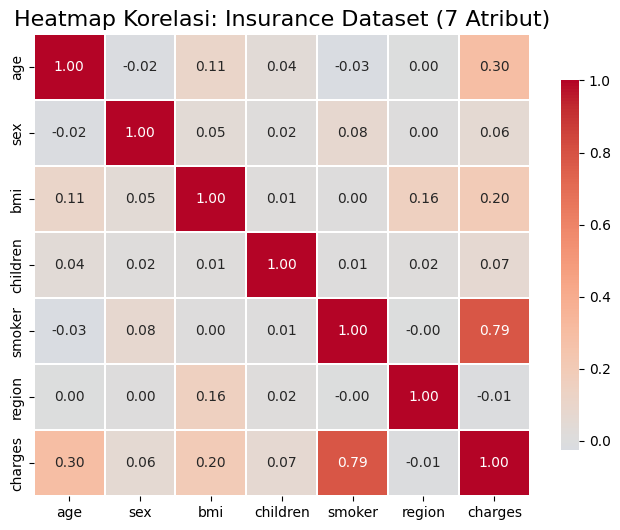

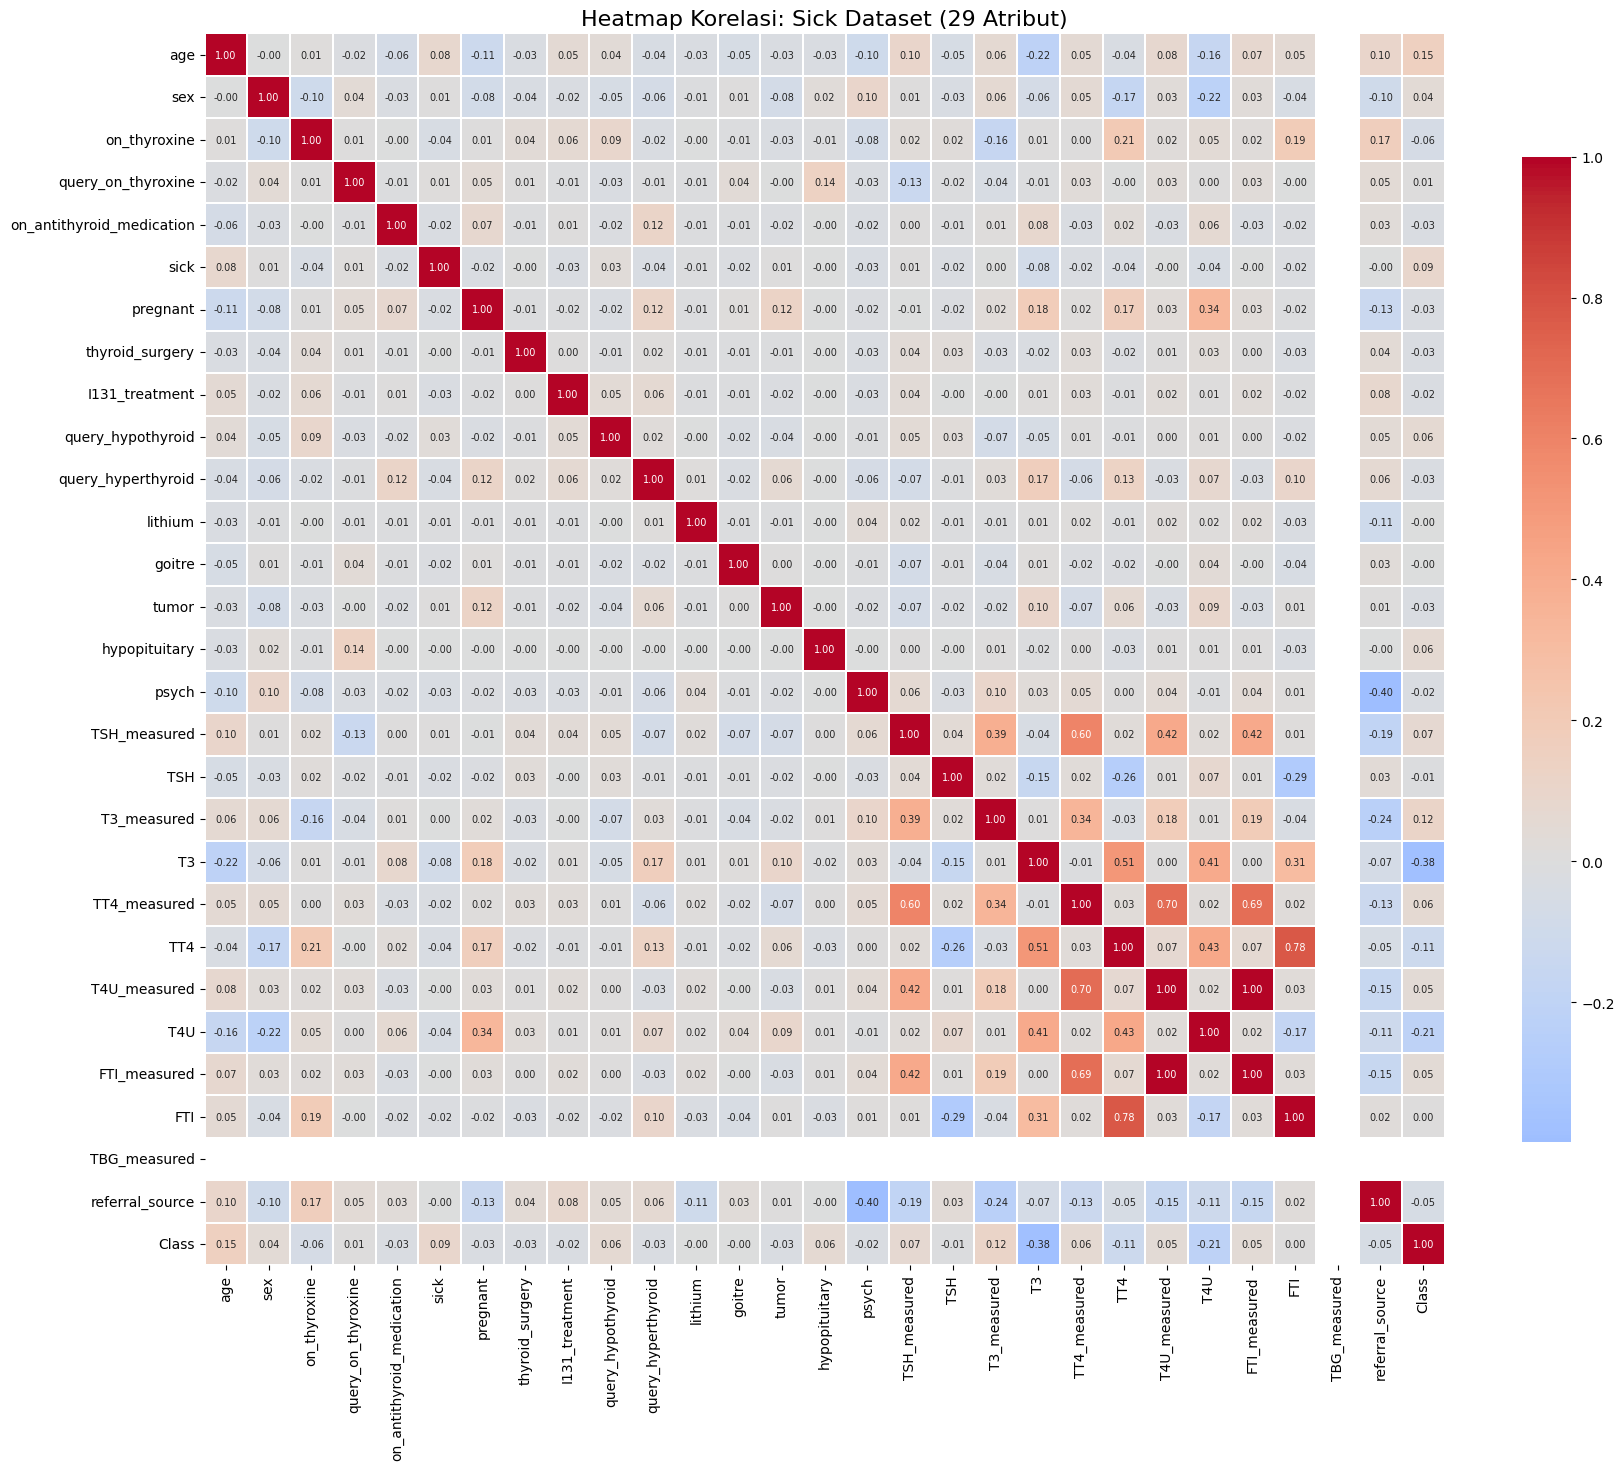

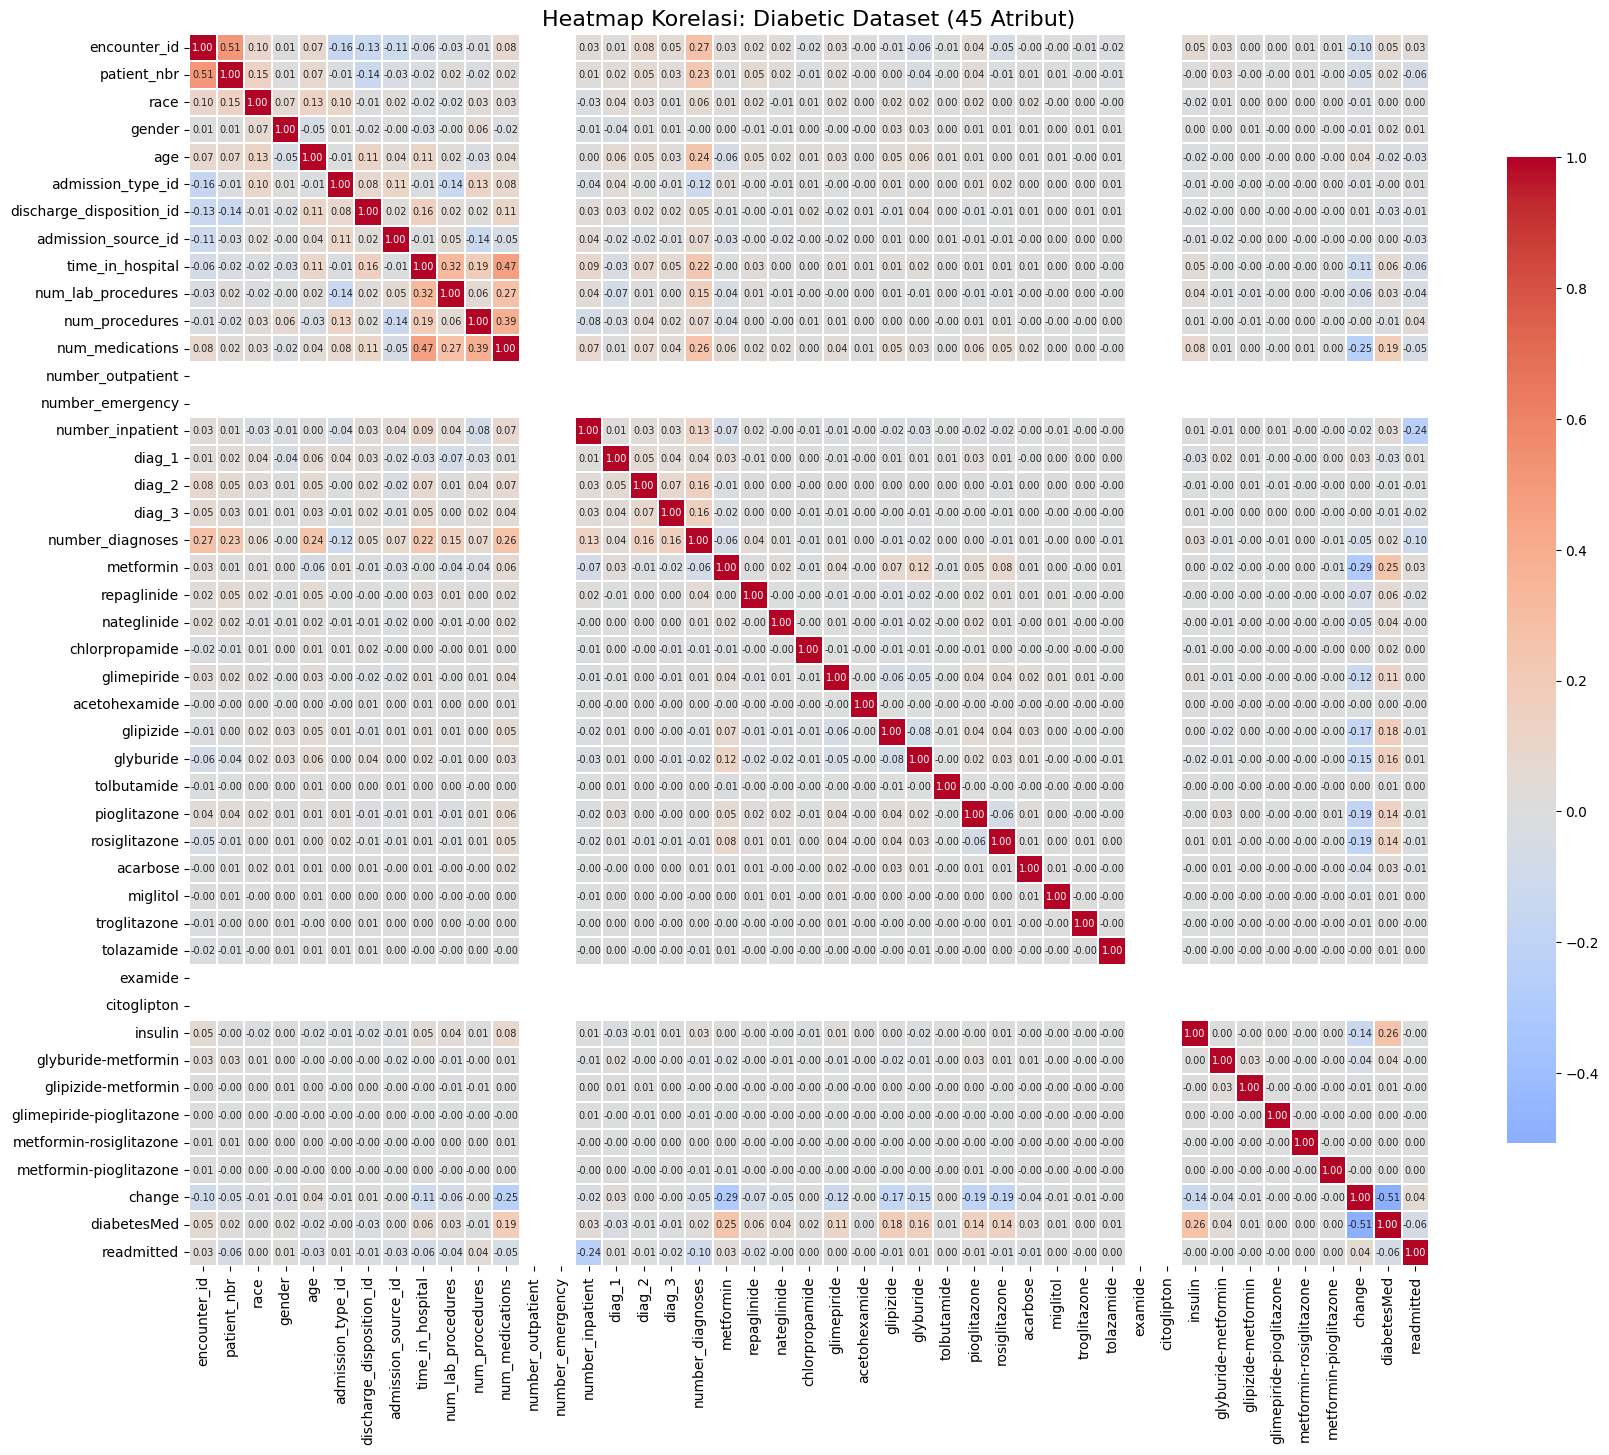

In [ ]:

def plot_correlation_heatmap(df, title, expected_cols):

    df_encoded = df.copy()
    le = LabelEncoder()

    for col in df_encoded.columns:
        if df_encoded[col].dtype == 'object':
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

    corr_matrix = df_encoded.corr()

    fig_size = (8, 6) if expected_cols < 10 else (20, 16)
    plt.figure(figsize=fig_size)

    font_size = 10 if expected_cols < 10 else 7

    sns.heatmap(corr_matrix,
                annot=True,
                fmt=".2f",
                cmap='coolwarm',
                center=0,
                linewidths=0.2,
                annot_kws={"size": font_size},
                cbar_kws={'shrink': .8})

    plt.title(f'Heatmap Korelasi: {title} ({corr_matrix.shape[0]} Atribut)', fontsize=16)
    plt.show()

plot_correlation_heatmap(insurance, "Insurance Dataset", 7)

plot_correlation_heatmap(sick, "Sick Dataset", 27)

plot_correlation_heatmap(diabetic, "Diabetic Dataset", 46)

In [ ]:
insurance = insurance.drop(columns=['region', 'children'])
print(f"Fitur tersisa INSURANCE : {insurance.shape[1]}")

Fitur tersisa INSURANCE : 5


In [ ]:
diabetic = diabetic.drop(columns=[
    'encounter_id',
    'examide',
    'citoglipton',
    'acetohexamide',
    'troglitazone',
    'tolazamide',
    'patient_nbr',
])
print(f"Fitur tersisa DIABETIC : {diabetic.shape[1]}")

Fitur tersisa DIABETIC : 38


In [ ]:
sick = sick.drop(columns=['TBG_measured','referral_source'])
print(f"Fitur tersisa SICK : {sick.shape[1]}")

Fitur tersisa SICK : 27


#10.Penyamaan isi data Atribut

In [ ]:
import pandas as pd

def cek_kategori(df, nama_df):
    print(f"\n==================== {nama_df.upper()} ====================")

    for col in df.columns:
        print(f"\n📌 {col.upper()}")

        # Hitung jumlah & persentase
        vc = df[col].value_counts(dropna=False)
        persen = df[col].value_counts(normalize=True, dropna=False) * 100

        # Gabungkan jadi tabel
        hasil = pd.DataFrame({
            'Kategori': vc.index,
            'Jumlah': vc.values,
            'Persentase (%)': persen.values.round(2)
        })

        # Reset index biar rapi
        hasil = hasil.reset_index(drop=True)

        print(hasil)

# Jalankan untuk semua dataset
cek_kategori(sick, "sick")
cek_kategori(insurance, "insurance")
cek_kategori(diabetic, "diabetic")


==================== SICK ====================

📌 AGE
    Kategori  Jumlah  Persentase (%)
0       59.0      95            2.56
1       60.0      90            2.43
2       70.0      88            2.37
3       73.0      81            2.18
4       55.0      79            2.13
..       ...     ...             ...
88      10.0       1            0.03
89       4.0       1            0.03
90       5.0       1            0.03
91     455.0       1            0.03
92       6.0       1            0.03

[93 rows x 3 columns]

📌 SEX
  Kategori  Jumlah  Persentase (%)
0        F    2571           69.32
1        M    1138           30.68

📌 ON_THYROXINE
  Kategori  Jumlah  Persentase (%)
0        f    3245           87.49
1        t     464           12.51

📌 QUERY_ON_THYROXINE
  Kategori  Jumlah  Persentase (%)
0        f    3659           98.65
1        t      50            1.35

📌 ON_ANTITHYROID_MEDICATION
  Kategori  Jumlah  Persentase (%)
0        f    3667           98.87
1        t      42 

##10.1 Mengubah gender menjadi sex

In [ ]:
diabetic.rename(columns={'gender': 'sex'}, inplace=True)
display(diabetic.head())

,race,sex,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,miglitol,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,NO
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,NO
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


##10.2 Menyamakan isi atribut Sex menjadi Female dan Male

In [ ]:
print(f"sick      : {sick['sex'].unique()}")
print(f"insurance : {insurance['sex'].unique()}")
print(f"diabetic  : {diabetic['sex'].unique()}")

sick      : ['F' 'M']
insurance : ['female' 'male']
diabetic  : ['Female' 'Male']


In [ ]:
sick['sex']      = sick['sex'].map({'F': 'Female', 'M': 'Male'})
insurance['sex'] = insurance['sex'].map({'female': 'Female', 'male': 'Male'})

print(f"sick      : {sick['sex'].unique()}")
print(f"insurance : {insurance['sex'].unique()}")
print(f"diabetic  : {diabetic['sex'].unique()}")

sick      : ['Female' 'Male']
insurance : ['Female' 'Male']
diabetic  : ['Female' 'Male']


##10.3 Menyamakan data No di Readmitted

In [ ]:
diabetic['readmitted'] = diabetic['readmitted'].replace({'NO': 'No'})
print(diabetic['readmitted'].unique())

['No' '>30' '<30']


##10.4 Menyamakan huruf kapital di Smoker(Yes dan No)

In [ ]:
insurance['smoker'] = insurance['smoker'].str.capitalize()
print(insurance['smoker'].unique())

['Yes' 'No']


##10.5 Mengubah t menjadi Yes,dan f menjadi No(dataset sick)

In [ ]:
cols = [
    'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication',
    'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
    'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre',
    'tumor', 'hypopituitary', 'psych', 'TSH_measured',
    'T3_measured', 'TT4_measured', 'T4U_measured', 'FTI_measured'
]

for col in cols:
    sick[col] = sick[col].map({'t': 'Yes', 'f': 'No'})

print(sick[cols].apply(lambda x: x.unique()).to_dict())

{'on_thyroxine': {0: 'No', 1: 'Yes'}, 'query_on_thyroxine': {0: 'No', 1: 'Yes'}, 'on_antithyroid_medication': {0: 'No', 1: 'Yes'}, 'sick': {0: 'No', 1: 'Yes'}, 'pregnant': {0: 'No', 1: 'Yes'}, 'thyroid_surgery': {0: 'No', 1: 'Yes'}, 'I131_treatment': {0: 'No', 1: 'Yes'}, 'query_hypothyroid': {0: 'No', 1: 'Yes'}, 'query_hyperthyroid': {0: 'No', 1: 'Yes'}, 'lithium': {0: 'No', 1: 'Yes'}, 'goitre': {0: 'No', 1: 'Yes'}, 'tumor': {0: 'No', 1: 'Yes'}, 'hypopituitary': {0: 'No', 1: 'Yes'}, 'psych': {0: 'No', 1: 'Yes'}, 'TSH_measured': {0: 'Yes', 1: 'No'}, 'T3_measured': {0: 'Yes', 1: 'No'}, 'TT4_measured': {0: 'Yes', 1: 'No'}, 'T4U_measured': {0: 'Yes', 1: 'No'}, 'FTI_measured': {0: 'Yes', 1: 'No'}}


In [ ]:
sick.head()

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,Class
0,41.0,Female,No,No,No,No,No,No,No,No,...,1.30,Yes,2.5,Yes,125.0,Yes,1.14,Yes,109.0,negative
1,23.0,Female,No,No,No,No,No,No,No,No,...,4.10,Yes,2.0,Yes,102.0,No,0.98,No,107.0,negative
2,46.0,Male,No,No,No,No,No,No,No,No,...,0.98,No,2.0,Yes,109.0,Yes,0.91,Yes,120.0,negative
3,70.0,Female,Yes,No,No,No,No,No,No,No,...,0.16,Yes,1.9,Yes,175.0,No,0.98,No,107.0,negative
4,70.0,Female,No,No,No,No,No,No,No,No,...,0.72,Yes,1.2,Yes,61.0,Yes,0.87,Yes,70.0,negative


In [ ]:
diabetic.head()

,race,sex,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,miglitol,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,No
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,No
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,No
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,No


# 11.Download Dataset setelah Pra Pemrosesan

In [ ]:
from google.colab import files
import zipfile

insurance.to_csv('insurance_preprocessed.csv', index=False)
diabetic.to_csv('diabetes_preprocessed.csv', index=False)
sick.to_csv('sick_preprocessed.csv', index=False)

with zipfile.ZipFile('New_Dataset.zip', 'w') as zipf:
    zipf.write('insurance_preprocessed.csv')
    zipf.write('diabetes_preprocessed.csv')
    zipf.write('sick_preprocessed.csv')

print("✅ Semua dataset berhasil disimpan dan dibuat ZIP!")
print("📥 Klik link di bawah ini untuk download...")

files.download('New_Dataset.zip')

✅ Semua dataset berhasil disimpan dan dibuat ZIP!
📥 Klik link di bawah ini untuk download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#12.Upload Dataset Setelah Pre-processing

In [11]:
sickfinal      = pd.read_csv('/content/drive/MyDrive/Dataset GPT 4/sick_preprocessed.csv')
insurancefinal = pd.read_csv('/content/drive/MyDrive/Dataset GPT 4/insurance_preprocessed.csv')
diabeticfinal  = pd.read_csv('/content/drive/MyDrive/Dataset GPT 4/diabetes_preprocessed.csv')

#13.Analisis Dataset setelah Pre-Processing

##13.1 Insurance

In [ ]:
cat_cols = ['sex', 'smoker']

num_cols = ['age', 'bmi', 'charges']

print("=== DISTRIBUSI KATEGORIK ===\n")

for col in cat_cols:
    dist = insurance[col].value_counts(normalize=True).round(4)

    print(f"{col}:")

    for category, prop in dist.items():
        print(f"  {str(category):<12} {prop:>6.4f}")

    print()

print("=== STATISTIK NUMERIK ===\n")
print(insurance[num_cols].describe().round(2))

=== DISTRIBUSI KATEGORIK ===

sex:
  Male         0.5049
  Female       0.4951

smoker:
  No           0.7951
  Yes          0.2049

=== STATISTIK NUMERIK ===

           age      bmi   charges
count  1337.00  1337.00   1337.00
mean     39.22    30.66  13279.12
std      14.04     6.10  12110.36
min      18.00    15.96   1121.87
25%      27.00    26.29   4746.34
50%      39.00    30.40   9386.16
75%      51.00    34.70  16657.72
max      64.00    53.13  63770.43


##13.2 Sick

In [ ]:
cat_cols = [
    'sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication',
    'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
    'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre',
    'tumor', 'hypopituitary', 'psych',
    'TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured', 'FTI_measured',
    'Class'
]

num_cols = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']

print("=== DISTRIBUSI KATEGORIK ===\n")

for col in cat_cols:
    dist = sick[col].value_counts(normalize=True).round(4)

    # Header kolom
    print(f"{col}:")

    for category, prop in dist.items():

        print(f"  {str(category):<20} {prop:>6.4f}")

    print()

print("=== STATISTIK NUMERIK ===\n")
print(sick[num_cols].describe().round(4))

=== DISTRIBUSI KATEGORIK ===

sex:
  Female               0.6932
  Male                 0.3068

on_thyroxine:
  No                   0.8749
  Yes                  0.1251

query_on_thyroxine:
  No                   0.9865
  Yes                  0.0135

on_antithyroid_medication:
  No                   0.9887
  Yes                  0.0113

sick:
  No                   0.9604
  Yes                  0.0396

pregnant:
  No                   0.9857
  Yes                  0.0143

thyroid_surgery:
  No                   0.9857
  Yes                  0.0143

I131_treatment:
  No                   0.9841
  Yes                  0.0159

query_hypothyroid:
  No                   0.9369
  Yes                  0.0631

query_hyperthyroid:
  No                   0.9369
  Yes                  0.0631

lithium:
  No                   0.9951
  Yes                  0.0049

goitre:
  No                   0.9908
  Yes                  0.0092

tumor:
  No                   0.9741
  Yes                  0.0259


##13.3 Diabetic

In [ ]:
cat_cols = [
    'race', 'sex', 'age', 'admission_type_id', 'discharge_disposition_id',
    'admission_source_id', 'metformin', 'repaglinide', 'nateglinide',
    'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin',
    'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
    'diabetesMed', 'readmitted'
]

num_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses'
]

print("=== DISTRIBUSI KATEGORIK ===\n")

for col in cat_cols:
    dist = diabeticfinal[col].value_counts(normalize=True).round(4)

    print(f"{col}:")

    for category, prop in dist.items():
        print(f"  {str(category):<20} {prop:>6.4f}")

    print()

print("=== STATISTIK NUMERIK ===\n")
print(diabeticfinal[num_cols].describe().round(2))

=== DISTRIBUSI KATEGORIK ===

race:
  Caucasian            0.7701
  AfricanAmerican      0.1888
  Hispanic             0.0200
  Other                0.0148
  Asian                0.0063

sex:
  Female               0.5376
  Male                 0.4624

age:
  [70-80)              0.2562
  [60-70)              0.2209
  [50-60)              0.1696
  [80-90)              0.1690
  [40-50)              0.0952
  [30-40)              0.0371
  [90-100)             0.0274
  [20-30)              0.0163
  [10-20)              0.0068
  [0-10)               0.0016

admission_type_id:
  1                    0.5305
  3                    0.1854
  2                    0.1816
  6                    0.0520
  5                    0.0470
  8                    0.0031
  7                    0.0002
  4                    0.0001

discharge_disposition_id:
  1                    0.5919
  3                    0.1371
  6                    0.1268
  18                   0.0363
  2                    0.0209
  22 

#14.Pembuatan Rules data yang akan digenerate GPT 4 (dalam format JSON)

##14.1 Rules Data Insurance

In [ ]:
import json
from google.colab import files

insurance_schema = {
  "dataset_name": "insurance_preprocessed",
  "description": "Dataset biaya asuransi kesehatan individu untuk memprediksi charges (biaya).",
  "source_info": {
    "total_rows": 1337,
    "total_columns": 5,
    "target_column": "charges"
  },
  "columns": {
    "age": {
      "type": "integer",
      "min": 18,
      "max": 64,
      "mean": 39.22,
      "std": 14.04,
      "percentiles": {
        "25%": 27,
        "50%": 39,
        "75%": 51
      },
      "null_allowed": False
    },
    "sex": {
      "type": "categorical",
      "allowed_values": [
        "Male",
        "Female"
      ],
      "distribution": {
        "Male": 0.5049,
        "Female": 0.4951
      },
      "null_allowed": False
    },
    "bmi": {
      "type": "float",
      "min": 15.96,
      "max": 53.13,
      "mean": 30.66,
      "std": 6.1,
      "percentiles": {
        "25%": 26.29,
        "50%": 30.4,
        "75%": 34.7
      },
      "note": "Body Mass Index. Normal: 18.5-24.9, Overweight: 25-29.9, Obese: >= 30",
      "null_allowed": False
    },
    "smoker": {
      "type": "categorical",
      "allowed_values": [
        "Yes",
        "No"
      ],
      "distribution": {
        "No": 0.7951,
        "Yes": 0.2049
      },
      "null_allowed": False
    },
    "charges": {
      "type": "float",
      "description": "TARGET - Biaya asuransi kesehatan dalam USD",
      "min": 1121.87,
      "max": 63770.43,
      "mean": 13279.12,
      "std": 12110.36,
      "percentiles": {
        "25%": 4746.34,
        "50%": 9386.16,
        "75%": 16657.72
      },
      "note": "Distribusi right-skewed. Perokok cenderung memiliki charges jauh lebih tinggi",
      "null_allowed": False
    }
  },
  "business_rules": [
    "age harus antara 18 dan 64 (inklusif).",
    "bmi harus bernilai positif, realistis antara 15 dan 55.",
    "smoker hanya boleh bernilai Yes atau No.",
    "sex hanya boleh bernilai Male atau Female.",
    "charges harus bernilai positif.",
    "Perokok (smoker=Yes) cenderung memiliki charges lebih tinggi dari non-perokok.",
    "BMI tinggi (>= 30) cenderung berkorelasi dengan charges lebih tinggi.",
    "Usia lebih tua cenderung memiliki charges lebih tinggi."
  ]
}

In [ ]:
with open("insurance_schema.json", "w", encoding="utf-8") as f:
    json.dump(insurance_schema, f, indent=4, ensure_ascii=False)

print("\nFile insurance_schema.json berhasil dibuat.")

files.download("insurance_schema.json")


File insurance_schema.json berhasil dibuat.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##14.2 Rules Data Sick

In [ ]:
import json
from google.colab import files

sick_schema = {
    "dataset_name": "sick_preprocessed",
    "description": "Dataset diagnosis penyakit tiroid untuk memprediksi apakah pasien menderita penyakit tiroid.",
    "source_info": {
        "total_rows": 3709,
        "total_columns": 27,
        "target_column": "Class"
    },
    "columns": {
        "age": {
            "type": "float",
            "min": 1,
            "max": 455,
            "mean": 51.86,
            "std": 20.13,
            "percentiles": {
                "25%": 36,
                "50%": 54,
                "75%": 67
            },
            "note": "Mayoritas usia 36-67 tahun. Nilai 455 kemungkinan data anomali/outlier",
            "null_allowed": False
        },
        "sex": {
            "type": "categorical",
            "allowed_values": ["Female", "Male"],
            "distribution": {"Female": 0.6932, "Male": 0.3068},
            "null_allowed": False
        },
        "on_thyroxine": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"No": 0.8749, "Yes": 0.1251},
            "note": "Apakah pasien sedang mengonsumsi obat tiroksin",
            "null_allowed": False
        },
        "query_on_thyroxine": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"No": 0.9865, "Yes": 0.0135},
            "note": "Apakah ada pertanyaan terkait konsumsi tiroksin",
            "null_allowed": False
        },
        "on_antithyroid_medication": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"No": 0.9887, "Yes": 0.0113},
            "note": "Apakah pasien sedang mengonsumsi obat antitiroid",
            "null_allowed": False
        },
        "sick": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"No": 0.9604, "Yes": 0.0396},
            "note": "Apakah pasien merasa sakit",
            "null_allowed": False
        },
        "pregnant": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"No": 0.9857, "Yes": 0.0143},
            "note": "Apakah pasien sedang hamil",
            "null_allowed": False
        },
        "thyroid_surgery": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"No": 0.9857, "Yes": 0.0143},
            "note": "Apakah pasien memiliki riwayat operasi tiroid",
            "null_allowed": False
        },
        "I131_treatment": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"No": 0.9841, "Yes": 0.0159},
            "note": "Apakah pasien pernah menjalani terapi radioiodine I-131",
            "null_allowed": False
        },
        "query_hypothyroid": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"No": 0.9369, "Yes": 0.0631},
            "note": "Apakah pasien diduga menderita hipotiroid",
            "null_allowed": False
        },
        "query_hyperthyroid": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"No": 0.9369, "Yes": 0.0631},
            "note": "Apakah pasien diduga menderita hipertiroid",
            "null_allowed": False
        },
        "lithium": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"No": 0.9951, "Yes": 0.0049},
            "note": "Apakah pasien mengonsumsi lithium",
            "null_allowed": False
        },
        "goitre": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"No": 0.9908, "Yes": 0.0092},
            "note": "Apakah pasien memiliki gondok (pembesaran kelenjar tiroid)",
            "null_allowed": False
        },
        "tumor": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"No": 0.9741, "Yes": 0.0259},
            "note": "Apakah pasien memiliki tumor",
            "null_allowed": False
        },
        "hypopituitary": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"No": 0.9997, "Yes": 0.0003},
            "note": "Apakah pasien memiliki gangguan hipofisis. Hampir semua bernilai No",
            "null_allowed": False
        },
        "psych": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"No": 0.9504, "Yes": 0.0496},
            "note": "Apakah pasien memiliki gangguan psikiatri",
            "null_allowed": False
        },
        "TSH_measured": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"Yes": 0.9172, "No": 0.0828},
            "note": "Apakah TSH diukur pada pasien",
            "null_allowed": False
        },
        "TSH": {
            "type": "float",
            "min": 0.005,
            "max": 530,
            "mean": 4.78,
            "std": 23.51,
            "percentiles": {"25%": 0.58, "50%": 1.4, "75%": 2.5},
            "note": "Kadar Thyroid Stimulating Hormone. Distribusi sangat right-skewed. Normal: 0.4-4.0 mIU/L",
            "null_allowed": False
        },
        "T3_measured": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"Yes": 0.8094, "No": 0.1906},
            "note": "Apakah T3 diukur pada pasien",
            "null_allowed": False
        },
        "T3": {
            "type": "float",
            "min": 0.05,
            "max": 10.6,
            "mean": 2.01,
            "std": 0.74,
            "percentiles": {"25%": 1.7, "50%": 2, "75%": 2.3},
            "note": "Kadar hormon T3. Normal: 1.2-3.1 nmol/L",
            "null_allowed": False
        },
        "TT4_measured": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"Yes": 0.9544, "No": 0.0456},
            "note": "Apakah Total T4 diukur pada pasien",
            "null_allowed": False
        },
        "TT4": {
            "type": "float",
            "min": 2,
            "max": 430,
            "mean": 108.09,
            "std": 34.8,
            "percentiles": {"25%": 89, "50%": 103, "75%": 123},
            "note": "Kadar Total T4. Normal: 60-150 nmol/L",
            "null_allowed": False
        },
        "T4U_measured": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"Yes": 0.9124, "No": 0.0876},
            "note": "Apakah T4U diukur pada pasien",
            "null_allowed": False
        },
        "T4U": {
            "type": "float",
            "min": 0.25,
            "max": 2.32,
            "mean": 0.99,
            "std": 0.19,
            "percentiles": {"25%": 0.89, "50%": 0.98, "75%": 1.07},
            "note": "T4 Uptake ratio. Normal: 0.85-1.15",
            "null_allowed": False
        },
        "FTI_measured": {
            "type": "categorical",
            "allowed_values": ["Yes", "No"],
            "distribution": {"Yes": 0.9129, "No": 0.0871},
            "note": "Apakah Free Thyroxine Index diukur pada pasien",
            "null_allowed": False
        },
        "FTI": {
            "type": "float",
            "min": 2,
            "max": 395,
            "mean": 110.18,
            "std": 31.63,
            "percentiles": {"25%": 94, "50%": 107, "75%": 122},
            "note": "Free Thyroxine Index = (TT4 x T4U). Normal: 70-140",
            "null_allowed": False
        },
        "Class": {
            "type": "categorical",
            "description": "TARGET - Status diagnosis tiroid pasien",
            "allowed_values": ["negative", "sick"],
            "distribution": {"negative": 0.9377, "sick": 0.0623},
            "note": "Sangat imbalanced: 93.8% negative, 6.2% sick",
            "null_allowed": False
        }
    },
    "business_rules": [
        "age harus bernilai positif. Nilai di atas 100 sangat jarang dan perlu diverifikasi.",
        "sex hanya boleh bernilai Female atau Male.",
        "Semua kolom biner (on_thyroxine, query_on_thyroxine, on_antithyroid_medication, sick, pregnant, thyroid_surgery, I131_treatment, query_hypothyroid, query_hyperthyroid, lithium, goitre, tumor, hypopituitary, psych) hanya boleh bernilai Yes atau No.",
        "Semua kolom _measured (TSH_measured, T3_measured, TT4_measured, T4U_measured, FTI_measured) hanya boleh bernilai Yes atau No.",
        "TSH, T3, TT4, T4U, FTI harus bernilai positif.",
        "Jika TSH_measured=No, nilai TSH tetap ada karena sudah diimputasi dengan median.",
        "pregnant=Yes hanya realistis untuk pasien sex=Female.",
        "hypopituitary=Yes sangat jarang (0.03%), generate dengan sangat hati-hati.",
        "Class sangat imbalanced: 93.8% negative, 6.2% sick.",
        "Pasien dengan Class=sick cenderung memiliki nilai TSH, T3, TT4, FTI di luar rentang normal."
    ]
}

In [ ]:
with open("sick_schema.json", "w", encoding="utf-8") as f:
    json.dump(sick_schema, f, indent=4, ensure_ascii=False)

print("\nFile sick_schema.json berhasil dibuat.")

files.download("sick_schema.json")


File sick_schema.json berhasil dibuat.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##14.3 Rules Data Diabetic

In [ ]:
import json
from google.colab import files

diabetic_schema = {
  "dataset_name": "diabetes_preprocessed",
  "description": "Dataset pasien diabetes rawat inap untuk memprediksi readmission ke rumah sakit.",
  "source_info": {
    "total_rows": 101766,
    "total_columns": 38,
    "target_column": "readmitted"
  },
  "columns": {
    "race": {
      "type": "categorical",
      "allowed_values": [
        "Caucasian",
        "AfricanAmerican",
        "Hispanic",
        "Other",
        "Asian"
      ],
      "distribution": {
        "Caucasian": 0.7701,
        "AfricanAmerican": 0.1888,
        "Hispanic": 0.02,
        "Other": 0.0148,
        "Asian": 0.0063
      },
      "null_allowed": False
    },
    "sex": {
      "type": "categorical",
      "allowed_values": [
        "Female",
        "Male"
      ],
      "distribution": {
        "Female": 0.5376,
        "Male": 0.4624
      },
      "null_allowed": False
    },
    "age": {
      "type": "categorical",
      "description": "Rentang usia format interval 10 tahun",
      "allowed_values": [
        "[0-10)",
        "[10-20)",
        "[20-30)",
        "[30-40)",
        "[40-50)",
        "[50-60)",
        "[60-70)",
        "[70-80)",
        "[80-90)",
        "[90-100)"
      ],
      "distribution": {
        "[0-10)": 0.0016,
        "[10-20)": 0.0068,
        "[20-30)": 0.0163,
        "[30-40)": 0.0371,
        "[40-50)": 0.0952,
        "[50-60)": 0.1696,
        "[60-70)": 0.2209,
        "[70-80)": 0.2562,
        "[80-90)": 0.169,
        "[90-100)": 0.0274
      },
      "null_allowed": False
    },
    "admission_type_id": {
      "type": "categorical",
      "description": "1=Emergency, 2=Urgent, 3=Elective, 4=Newborn, 5=Not Available, 6=NULL, 7=Trauma, 8=Not Mapped",
      "allowed_values": [
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8
      ],
      "distribution": {
        "1": 0.5305,
        "2": 0.1816,
        "3": 0.1854,
        "4": 0.0001,
        "5": 0.047,
        "6": 0.052,
        "7": 0.0002,
        "8": 0.0031
      },
      "null_allowed": False
    },
    "discharge_disposition_id": {
      "type": "categorical",
      "description": "1=Discharged to home, 2=Short-term hospital, 3=SNF, 4=ICF, 5=Another facility, 6=Home health service, 7=AMA, 8=Home IV, 9=Admitted inpatient, 11=Expired, 13=Hospice/home, 14=Hospice/facility, 18=Not Mapped, 22=Rehab, 23=Long-term care, 25=Not Mapped, 28=Psychiatric hospital",
      "allowed_values": [
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10,
        11,
        12,
        13,
        14,
        15,
        16,
        17,
        18,
        19,
        20,
        22,
        23,
        24,
        25,
        27,
        28
      ],
      "distribution": {
        "1": 0.5919,
        "2": 0.0209,
        "3": 0.1371,
        "4": 0.008,
        "5": 0.0116,
        "6": 0.1268,
        "7": 0.0061,
        "8": 0.0011,
        "9": 0.0002,
        "10": 0.0001,
        "11": 0.0161,
        "12": 0,
        "13": 0.0039,
        "14": 0.0037,
        "15": 0.0006,
        "16": 0.0001,
        "17": 0.0001,
        "18": 0.0363,
        "19": 0.0001,
        "20": 0,
        "22": 0.0196,
        "23": 0.004,
        "24": 0.0005,
        "25": 0.0097,
        "27": 0,
        "28": 0.0014
      },
      "null_allowed": False
    },
    "admission_source_id": {
      "type": "categorical",
      "description": "1=Physician referral, 2=Clinic referral, 3=HMO referral, 4=Transfer from hospital, 5=Transfer SNF, 6=Transfer another, 7=Emergency room, 8=Court/law, 9=Not available, 10=Transfer critical, 11=Normal delivery, 13=Sick baby, 14=Extramural birth, 17=NULL, 20=Unknown, 22=Readmission, 25=Not mapped",
      "allowed_values": [
        1,
        2,
        3,
        4,
        5,
        6,
        7,
        8,
        9,
        10,
        11,
        13,
        14,
        17,
        20,
        22,
        25
      ],
      "distribution": {
        "1": 0.2905,
        "2": 0.0108,
        "3": 0.0018,
        "4": 0.0313,
        "5": 0.0084,
        "6": 0.0222,
        "7": 0.565,
        "8": 0.0002,
        "9": 0.0012,
        "10": 0.0001,
        "11": 0,
        "13": 0,
        "14": 0,
        "17": 0.0666,
        "20": 0.0016,
        "22": 0.0001,
        "25": 0
      },
      "null_allowed": False
    },
    "time_in_hospital": {
      "type": "integer",
      "min": 1,
      "max": 14,
      "mean": 4.4,
      "std": 2.99,
      "percentiles": {
        "25%": 2,
        "50%": 4,
        "75%": 6
      },
      "null_allowed": False
    },
    "num_lab_procedures": {
      "type": "integer",
      "min": 1,
      "max": 132,
      "mean": 43.1,
      "std": 19.67,
      "percentiles": {
        "25%": 31,
        "50%": 44,
        "75%": 57
      },
      "null_allowed": False
    },
    "num_procedures": {
      "type": "integer",
      "min": 0,
      "max": 6,
      "mean": 1.34,
      "std": 1.71,
      "percentiles": {
        "25%": 0,
        "50%": 1,
        "75%": 2
      },
      "null_allowed": False
    },
    "num_medications": {
      "type": "integer",
      "min": 1,
      "max": 81,
      "mean": 16.02,
      "std": 8.13,
      "percentiles": {
        "25%": 10,
        "50%": 15,
        "75%": 20
      },
      "null_allowed": False
    },
    "number_outpatient": {
      "type": "integer",
      "min": 0,
      "max": 0,
      "mean": 0,
      "std": 0,
      "percentiles": {
        "25%": 0,
        "50%": 0,
        "75%": 0
      },
      "note": "Selalu bernilai 0 di dataset ini (sudah difilter)",
      "null_allowed": False
    },
    "number_emergency": {
      "type": "integer",
      "min": 0,
      "max": 0,
      "mean": 0,
      "std": 0,
      "percentiles": {
        "25%": 0,
        "50%": 0,
        "75%": 0
      },
      "note": "Selalu bernilai 0 di dataset ini (sudah difilter)",
      "null_allowed": False
    },
    "number_inpatient": {
      "type": "float",
      "min": 0,
      "max": 2.5,
      "mean": 0.51,
      "std": 0.81,
      "percentiles": {
        "25%": 0,
        "50%": 0,
        "75%": 1
      },
      "note": "Zero-inflated, mayoritas 0. Nilai unik: 0.0, 1.0, 2.0, 2.5",
      "null_allowed": False
    },
    "diag_1": {
      "type": "categorical",
      "description": "Kode diagnosis utama ICD-9 (716 nilai unik). Bisa numerik, desimal, atau diawali V/E",
      "example_common_codes": [
        "428",
        "414",
        "786",
        "410",
        "276",
        "250",
        "401",
        "427"
      ],
      "null_allowed": False
    },
    "diag_2": {
      "type": "categorical",
      "description": "Kode diagnosis kedua ICD-9 (748 nilai unik). Bisa numerik, desimal, atau diawali V/E",
      "example_common_codes": [
        "276",
        "428",
        "250",
        "427",
        "414",
        "401"
      ],
      "null_allowed": False
    },
    "diag_3": {
      "type": "categorical",
      "description": "Kode diagnosis ketiga ICD-9 (789 nilai unik). Bisa numerik, desimal, atau diawali V/E",
      "example_common_codes": [
        "250",
        "401",
        "276",
        "428",
        "414"
      ],
      "null_allowed": False
    },
    "number_diagnoses": {
      "type": "integer",
      "min": 1,
      "max": 16,
      "mean": 7.42,
      "std": 1.93,
      "percentiles": {
        "25%": 6,
        "50%": 8,
        "75%": 9
      },
      "null_allowed": False
    },
    "metformin": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady",
        "Up",
        "Down"
      ],
      "distribution": {
        "No": 0.8036,
        "Steady": 0.1803,
        "Up": 0.0105,
        "Down": 0.0057
      },
      "null_allowed": False
    },
    "repaglinide": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady",
        "Up",
        "Down"
      ],
      "distribution": {
        "No": 0.9849,
        "Steady": 0.0136,
        "Up": 0.0011,
        "Down": 0.0004
      },
      "null_allowed": False
    },
    "nateglinide": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady",
        "Up",
        "Down"
      ],
      "distribution": {
        "No": 0.9931,
        "Steady": 0.0066,
        "Up": 0.0002,
        "Down": 0.0001
      },
      "null_allowed": False
    },
    "chlorpropamide": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady",
        "Up",
        "Down"
      ],
      "distribution": {
        "No": 0.9992,
        "Steady": 0.0008,
        "Up": 0.0001,
        "Down": 0
      },
      "null_allowed": False
    },
    "glimepiride": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady",
        "Up",
        "Down"
      ],
      "distribution": {
        "No": 0.949,
        "Steady": 0.0459,
        "Up": 0.0032,
        "Down": 0.0019
      },
      "null_allowed": False
    },
    "glipizide": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady",
        "Up",
        "Down"
      ],
      "distribution": {
        "No": 0.8753,
        "Steady": 0.1116,
        "Up": 0.0076,
        "Down": 0.0055
      },
      "null_allowed": False
    },
    "glyburide": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady",
        "Up",
        "Down"
      ],
      "distribution": {
        "No": 0.8953,
        "Steady": 0.0911,
        "Up": 0.008,
        "Down": 0.0055
      },
      "null_allowed": False
    },
    "tolbutamide": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady"
      ],
      "distribution": {
        "No": 0.9998,
        "Steady": 0.0002
      },
      "null_allowed": False
    },
    "pioglitazone": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady",
        "Up",
        "Down"
      ],
      "distribution": {
        "No": 0.928,
        "Steady": 0.0685,
        "Up": 0.0023,
        "Down": 0.0012
      },
      "null_allowed": False
    },
    "rosiglitazone": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady",
        "Up",
        "Down"
      ],
      "distribution": {
        "No": 0.9375,
        "Steady": 0.0599,
        "Up": 0.0017,
        "Down": 0.0009
      },
      "null_allowed": False
    },
    "acarbose": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady",
        "Up",
        "Down"
      ],
      "distribution": {
        "No": 0.997,
        "Steady": 0.0029,
        "Up": 0.0001,
        "Down": 0
      },
      "null_allowed": False
    },
    "miglitol": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady",
        "Down",
        "Up"
      ],
      "distribution": {
        "No": 0.9996,
        "Steady": 0.0003,
        "Down": 0,
        "Up": 0
      },
      "null_allowed": False
    },
    "insulin": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady",
        "Down",
        "Up"
      ],
      "distribution": {
        "No": 0.4656,
        "Steady": 0.3031,
        "Down": 0.1201,
        "Up": 0.1112
      },
      "note": "Insulin adalah obat paling umum digunakan, 53.4% pasien menggunakannya",
      "null_allowed": False
    },
    "glyburide-metformin": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady",
        "Up",
        "Down"
      ],
      "distribution": {
        "No": 0.9931,
        "Steady": 0.0068,
        "Up": 0.0001,
        "Down": 0.0001
      },
      "null_allowed": False
    },
    "glipizide-metformin": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady"
      ],
      "distribution": {
        "No": 0.9999,
        "Steady": 0.0001
      },
      "null_allowed": False
    },
    "glimepiride-pioglitazone": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady"
      ],
      "distribution": {
        "No": 1,
        "Steady": 0
      },
      "null_allowed": False
    },
    "metformin-rosiglitazone": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady"
      ],
      "distribution": {
        "No": 1,
        "Steady": 0
      },
      "null_allowed": False
    },
    "metformin-pioglitazone": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Steady"
      ],
      "distribution": {
        "No": 1,
        "Steady": 0
      },
      "null_allowed": False
    },
    "change": {
      "type": "categorical",
      "allowed_values": [
        "No",
        "Ch"
      ],
      "distribution": {
        "No": 0.538,
        "Ch": 0.462
      },
      "note": "Ch = ada perubahan dosis obat diabetes selama rawat inap",
      "null_allowed": False
    },
    "diabetesMed": {
      "type": "categorical",
      "allowed_values": [
        "Yes",
        "No"
      ],
      "distribution": {
        "Yes": 0.77,
        "No": 0.23
      },
      "null_allowed": False
    },
    "readmitted": {
      "type": "categorical",
      "description": "TARGET - Status readmission pasien",
      "allowed_values": [
        "NO",
        ">30",
        "<30"
      ],
      "distribution": {
        "NO": 0.5391,
        ">30": 0.3493,
        "<30": 0.1116
      },
      "null_allowed": False
    }
  },
  "business_rules": [
    "Semua kolom obat hanya boleh diisi: No, Steady, Up, Down. Obat kombinasi hanya No/Steady.",
    "Jika diabetesMed=No, maka semua kolom obat harus bernilai No.",
    "Jika diabetesMed=Yes, maka minimal satu kolom obat harus bernilai selain No.",
    "Jika change=Ch, maka minimal satu kolom obat harus bernilai Up atau Down.",
    "Jika change=No, maka semua kolom obat harus bernilai No atau Steady.",
    "time_in_hospital harus antara 1 dan 14 (inklusif).",
    "num_procedures harus antara 0 dan 6 (inklusif).",
    "num_medications harus antara 1 dan 81.",
    "number_diagnoses harus antara 1 dan 16.",
    "age menggunakan format bracket: [0-10), [10-20), ..., [90-100).",
    "number_outpatient dan number_emergency selalu bernilai 0.",
    "number_inpatient hanya boleh bernilai: 0.0, 1.0, 2.0, atau 2.5.",
    "diag_1, diag_2, diag_3 menggunakan kode ICD-9 valid (numerik, desimal, atau diawali huruf kapital V atau E).",
    "readmitted: 53.9% NO, 34.9% >30, 11.2% <30."
  ]
}

In [ ]:
with open("diabetic_schema.json", "w", encoding="utf-8") as f:
    json.dump(diabetic_schema, f, indent=4, ensure_ascii=False)

print("\nFile diabetic_schema.json berhasil dibuat.")

files.download("diabetic_schema.json")


File diabetic_schema.json berhasil dibuat.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#15.Upload JSON

In [12]:
import json

path_folder = "/content/drive/MyDrive/Dataset GPT 4/"

with open(path_folder + "insurance_schema.json", "r") as f:
    insurance_schema = json.load(f)

with open(path_folder + "sick_schema.json", "r") as f:
    sick_schema = json.load(f)

with open(path_folder + "diabetic_schema.json", "r") as f:
    diabetic_schema = json.load(f)

print("Semua schema berhasil di-load!")
print(f"  insurance : {insurance_schema['dataset_name']}")
print(f"  sick      : {sick_schema['dataset_name']}")
print(f"  diabetic  : {diabetic_schema['dataset_name']}")

Semua schema berhasil di-load!
  insurance : insurance_preprocessed
  sick      : sick_preprocessed
  diabetic  : diabetes_preprocessed


#16.Desain Prompt GPT-4

##16.1 Insurance Data

In [ ]:
#You are a synthetic medical data generator. Your job is to generate realistic
#insurance data that strictly follows the given schema and rules.
#
#=== SCHEMA ===
#{json.dumps(insurance_schema, indent=2)}
#
#=== REAL DATA EXAMPLES (use as reference for format and value range) ===
#age,sex,bmi,smoker,charges
#19,Female,27.9,Yes,16884.924
#18,Male,33.77,No,1725.5523
#28,Male,33.0,No,4449.462
#33,Male,22.705,No,21984.47061
#32,Male,28.88,No,3866.8552
#
#=== STEP BY STEP RULES (follow in order before generating) ===
#Step 1 - Check column types: age=integer, bmi=float, charges=float, sex/smoker=categorical
#Step 2 - Check value ranges: age 18-64, bmi 15.96-53.13, charges 1121.87-63770.43
#Step 3 - Check distribution: 79.5% smoker=No, 20.5% smoker=Yes
#Step 4 - Check business rules: smoker=Yes tends to have higher charges, older age tends to have higher charges
#Step 5 - Generate {n_rows} rows following all rules above
#
#Output ONLY a valid JSON array. No explanation. No markdown.#

##16.2 Sick Data

In [ ]:
# You are a synthetic medical data generator. Your job is to generate realistic
# thyroid diagnosis data that strictly follows the given schema and rules.

# === SCHEMA ===
# {json.dumps(sick_schema, indent=2)}

# === REAL DATA EXAMPLES (use as reference for format and value range) ===
# age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,
# thyroid_surgery,I131_treatment,query_hypothyroid,query_hyperthyroid,lithium,
# goitre,tumor,hypopituitary,psych,TSH_measured,TSH,T3_measured,T3,TT4_measured,
# TT4,T4U_measured,T4U,FTI_measured,FTI,Class
# 72,Female,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,1.4,Yes,2.0,Yes,103.0,Yes,0.98,Yes,107.0,negative
# 41,Male,Yes,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,0.2,Yes,1.8,Yes,93.0,Yes,0.9,Yes,100.0,negative
# 30,Female,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,5.4,Yes,2.2,Yes,87.0,Yes,1.01,Yes,92.0,sick

# === STEP BY STEP RULES (follow in order before generating) ===
# Step 1 - Check column types: age=float, TSH/T3/TT4/T4U/FTI=float, all others=categorical (Yes/No)
# Step 2 - Check value ranges: TSH 0.005-530, T3 0.05-10.6, TT4 2-430, T4U 0.25-2.32, FTI 2-395
# Step 3 - Check distribution: 93.8% Class=negative, 6.2% Class=sick
# Step 4 - Check binary columns: all boolean columns only Yes or No
# Step 5 - Check business rules: pregnant=Yes only if sex=Female, Class=sick tends to have abnormal TSH/T3/TT4 values
# Step 6 - Generate {n_rows} rows following all rules above

# Output ONLY a valid JSON array. No explanation. No markdown.

##16.3 Diabetic Data

In [ ]:
# You are a synthetic medical data generator. Your job is to generate realistic
# diabetic patient data that strictly follows the given schema and rules.

# === SCHEMA ===
# {json.dumps(diabetic_schema, indent=2)}

# === REAL DATA EXAMPLES (use as reference for format and value range) ===
# race,sex,age,admission_type_id,discharge_disposition_id,admission_source_id,
# time_in_hospital,num_lab_procedures,num_procedures,num_medications,
# number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,
# number_diagnoses,metformin,insulin,change,diabetesMed,readmitted
# Caucasian,Female,[70-80),1,1,7,3,41,0,1,0,0,0.0,250.83,276,250,9,No,No,No,No,NO
# AfricanAmerican,Male,[50-60),1,6,7,5,59,1,18,0,0,1.0,428,250,401,9,Steady,Up,Ch,Yes,>30
# Caucasian,Female,[60-70),3,1,1,2,44,2,16,0,0,0.0,414,276,250,9,No,Steady,No,Yes,NO

# === STEP BY STEP RULES (follow in order before generating) ===
# Step 1 - Check column types: age=bracket string, all medication cols=categorical, numeric cols=integer/float
# Step 2 - Check fixed values: number_outpatient=0, number_emergency=0
# Step 3 - Check number_inpatient: only 0.0, 1.0, 2.0, or 2.5
# Step 4 - Check medication rules: if diabetesMed=No then ALL medication cols must be No
# Step 5 - Check change rules: if change=Ch then at least one medication must be Up or Down
# Step 6 - Check distribution: 53.9% readmitted=NO, 34.9% >30, 11.2% <30
# Step 7 - Check diag codes: use valid ICD-9 codes (numeric, decimal, or starting with V or E)
# Step 8 - Generate {n_rows} rows following all rules above

# Output ONLY a valid JSON array. No explanation. No markdown.

# 17.Implementasi GPT-4 (Pembuatan Data Sintetis 20% dari masing masing dataset)

In [13]:
!pip install openai -q

In [14]:
from google.colab import userdata
import openai

client = openai.OpenAI(api_key=userdata.get('OPENAI_API_KEY'))

# Test koneksi
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "say hello"}],
    max_tokens=10
)
print("✅ API key valid:", response.choices[0].message.content)

✅ API key valid: Hello! How can I assist you today?


In [15]:
n_insurance = round(len(insurancefinal) * 0.20)
n_sick      = round(len(sickfinal)      * 0.20)
n_diabetic  = round(len(diabeticfinal)  * 0.20)

print(f"Insurance : {n_insurance} baris")
print(f"Sick      : {n_sick} baris")
print(f"Diabetic  : {n_diabetic} baris")

Insurance : 267 baris
Sick      : 742 baris
Diabetic  : 20353 baris


In [16]:
def get_fewshot_examples(df, n=20):
    sample = df.sample(n=min(n, len(df)), random_state=42)
    return sample.to_csv(index=False)

print("Fungsi few-shot sampler siap.")

Fungsi few-shot sampler siap.


In [17]:
def validate_and_clean_insurance(df):
    df = df.copy()
    before = len(df)

    df['age']     = pd.to_numeric(df['age'],     errors='coerce')
    df['bmi']     = pd.to_numeric(df['bmi'],     errors='coerce')
    df['charges'] = pd.to_numeric(df['charges'], errors='coerce')

    df = df.dropna(subset=['age', 'bmi', 'charges'])
    df = df[df['age'].between(18, 64)]
    df = df[df['bmi'].between(15, 55)]
    df = df[df['charges'] > 0]
    df = df[df['sex'].isin(['Male', 'Female'])]
    df = df[df['smoker'].isin(['Yes', 'No'])]
    df['age'] = df['age'].astype(int)

    after = len(df)
    print(f"[Insurance] Sebelum: {before} | Setelah: {after} | Drop: {before - after}")
    return df.reset_index(drop=True)


def validate_and_clean_sick(df):
    df = df.copy()
    before = len(df)

    num_cols = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']
    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=num_cols)

    df = df[df['age'] > 0]
    df = df[df['TSH'].between(0.005, 530)]
    df = df[df['T3'].between(0.05, 10.6)]
    df = df[df['TT4'].between(2, 430)]
    df = df[df['T4U'].between(0.25, 2.32)]
    df = df[df['FTI'].between(2, 395)]
    df = df[df['sex'].isin(['Female', 'Male'])]
    df = df[df['Class'].isin(['negative', 'sick'])]

    binary_cols = [
        'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication',
        'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
        'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre',
        'tumor', 'hypopituitary', 'psych',
        'TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured', 'FTI_measured'
    ]
    for col in binary_cols:
        if col in df.columns:
            df = df[df[col].isin(['Yes', 'No'])]

    invalid_pregnant = (df['pregnant'] == 'Yes') & (df['sex'] != 'Female')
    df = df[~invalid_pregnant]

    after = len(df)
    print(f"[Sick] Sebelum: {before} | Setelah: {after} | Drop: {before - after}")
    return df.reset_index(drop=True)


def validate_and_clean_diabetic(df):
    df = df.copy()
    before = len(df)

    med_cols = [
        'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
        'glimepiride', 'glipizide', 'glyburide', 'tolbutamide',
        'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin',
        'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone',
        'metformin-rosiglitazone', 'metformin-pioglitazone'
    ]

    for col in ['number_outpatient', 'number_emergency', 'number_inpatient']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df = df.dropna(subset=['number_outpatient', 'number_emergency', 'number_inpatient'])

    df = df[df['number_outpatient'] == 0]
    df = df[df['number_emergency'] == 0]
    df = df[df['number_inpatient'] >= 0]
    df = df[df['readmitted'].isin(['NO', '>30', '<30'])]
    df = df[df['age'].astype(str).str.match(r'^\[\d+-\d+\)$')]

    med_cols_present = [c for c in med_cols if c in df.columns]
    no_med_mask  = df['diabetesMed'] == 'No'
    valid_no_med = (df.loc[no_med_mask, med_cols_present] == 'No').all(axis=1)
    df = df[~no_med_mask | valid_no_med]

    ch_mask  = df['change'] == 'Ch'
    valid_ch = df.loc[ch_mask, med_cols_present].isin(['Up', 'Down']).any(axis=1)
    df = df[~ch_mask | valid_ch]

    no_ch_mask  = df['change'] == 'No'
    valid_no_ch = df.loc[no_ch_mask, med_cols_present].isin(['No', 'Steady']).all(axis=1)
    df = df[~no_ch_mask | valid_no_ch]

    after = len(df)
    print(f"[Diabetic] Sebelum: {before} | Setelah: {after} | Drop: {before - after}")
    return df.reset_index(drop=True)


print("Fungsi validasi & cleaning siap.")

Fungsi validasi & cleaning siap.


In [18]:
import concurrent.futures
import time

def build_prompt_insurance(schema, n_rows, fewshot_csv):
    return f"""You are a precise synthetic medical data generator.
Generate exactly {n_rows} rows of insurance data following ALL rules below.

=== SCHEMA ===
{json.dumps(schema, indent=2)}

=== REAL DATA EXAMPLES (use as reference for format, range, and distribution) ===
{fewshot_csv}

=== STEP-BY-STEP RULES (check in order before generating each row) ===
Step 1 - Column types: age=integer, bmi=float 2dp, charges=float 2dp, sex/smoker=categorical
Step 2 - Value ranges: age 18-64, bmi 15.96-53.13, charges 1121.87-63770.43
Step 3 - Distribution: generate exactly 79.5% smoker=No and 20.5% smoker=Yes across all rows
Step 4 - Distribution: generate exactly 50.5% sex=Male and 49.5% sex=Female

=== CAUSAL RELATIONSHIPS (IMPORTANT - affects utility score) ===
- If smoker=Yes: charges MUST be between 15000 and 63770
- If smoker=No AND age < 30: charges MUST be between 1121 and 5000
- If smoker=No AND age >= 30 AND age < 50: charges MUST be between 3000 and 18000
- If smoker=No AND age >= 50: charges MUST be between 5000 and 35000
- Higher bmi (>=30) tends toward higher charges, especially for smokers
- age positively correlates with charges

Output ONLY a valid JSON array. No explanation. No markdown. No extra text."""


def build_prompt_sick(schema, n_rows, fewshot_csv):
    return f"""You are a precise synthetic medical data generator.
Generate exactly {n_rows} rows of thyroid diagnosis data following ALL rules below.

=== SCHEMA ===
{json.dumps(schema, indent=2)}

=== REAL DATA EXAMPLES (use as reference for format, range, and distribution) ===
{fewshot_csv}

=== STEP-BY-STEP RULES (check in order before generating each row) ===
Step 1 - Column types: age=float, TSH/T3/TT4/T4U/FTI=float, all others=categorical Yes/No
Step 2 - Value ranges: TSH 0.005-530, T3 0.05-10.6, TT4 2-430, T4U 0.25-2.32, FTI 2-395
Step 3 - Distribution: generate exactly 93.8% Class=negative and 6.2% Class=sick
Step 4 - All binary columns MUST only be Yes or No (never true/false/1/0)
Step 5 - pregnant=Yes is ONLY allowed if sex=Female. NEVER pregnant=Yes with sex=Male.

=== CAUSAL RELATIONSHIPS (IMPORTANT - affects utility score) ===
- If Class=sick: TSH tends to be very high (>10) or very low (<0.1), T3 tends low (<1.0)
- If Class=negative: TSH typically 0.4-4.0, T3 typically 1.0-3.0, TT4 typically 60-150
- on_thyroxine=Yes tends to correlate with lower TSH values
- on_antithyroid_medication=Yes tends to correlate with lower T3/T4 values
- Distribution: 69.3% sex=Female, 30.7% sex=Male

WRONG example: {{"sex": "Male", "pregnant": "Yes", ...}}
RIGHT example: {{"sex": "Female", "pregnant": "Yes", ...}}

Output ONLY a valid JSON array. No explanation. No markdown. No extra text."""


def build_prompt_diabetic(schema, n_rows, fewshot_csv):
    return f"""You are a precise synthetic medical data generator.
Generate exactly {n_rows} rows of diabetic patient data following ALL rules below.

=== SCHEMA ===
{json.dumps(schema, indent=2)}

=== REAL DATA EXAMPLES (use as reference for format, range, and distribution) ===
{fewshot_csv}

=== STEP-BY-STEP RULES (check in order before generating each row) ===
Step 1 - Column types: age=bracket string like [60-70), medication cols=categorical, numeric=integer
Step 2 - FIXED VALUES: number_outpatient MUST always be 0, number_emergency MUST always be 0
Step 3 - number_inpatient MUST be >= 0 (integer)
Step 4 - Distribution: readmitted must be 53.9% NO, 34.9% >30, 11.2% <30
Step 5 - Distribution: race must be 77.0% Caucasian, 18.9% AfricanAmerican, 2.0% Hispanic, 1.5% Other, 0.6% Asian

=== MEDICATION RULES (check each row before output) ===
Rule A: If diabetesMed=No, then ALL medication columns MUST be 'No'
  WRONG: {{"diabetesMed": "No", "metformin": "Steady"}}
  RIGHT: {{"diabetesMed": "No", "metformin": "No"}}

Rule B: If change=Ch, then at least ONE medication column must be 'Up' or 'Down'
  WRONG: {{"change": "Ch", "metformin": "No", "insulin": "Steady"}}
  RIGHT: {{"change": "Ch", "insulin": "Up"}}

Rule C: If change=No, then ALL medication columns must be 'No' or 'Steady' only
  WRONG: {{"change": "No", "insulin": "Up"}}
  RIGHT: {{"change": "No", "insulin": "Steady"}}

=== CAUSAL RELATIONSHIPS (IMPORTANT - affects utility score) ===
- Higher number_inpatient tends to correlate with readmitted=<30
- Longer time_in_hospital tends to correlate with more num_medications
- diabetesMed=Yes tends to correlate with readmitted in >30 or <30
- age bracket [70-80) and [80-90) are most common (25.6% and 16.9%)

Output ONLY a valid JSON array. No explanation. No markdown. No extra text."""


print("Fungsi prompt builder siap.")

Fungsi prompt builder siap.


In [19]:
def generate_batch_parallel(schema, n_rows, fewshot_csv, prompt_builder, batch_size=10):
    all_data = []
    batches  = [batch_size] * (n_rows // batch_size)
    if n_rows % batch_size:
        batches.append(n_rows % batch_size)

    def call_api(jumlah, idx):
        try:
            prompt = prompt_builder(schema, jumlah, fewshot_csv)

            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {
                        "role": "system",
                        "content": "You are a precise synthetic data generator. Respond ONLY with a valid JSON array. No explanation. No markdown."
                    },
                    {"role": "user", "content": prompt}
                ],
                temperature=0.5,
                max_tokens=4096
            )
            raw = response.choices[0].message.content.strip()

            if "```" in raw:
                raw = raw.split("```")[1]
                if raw.startswith("json"):
                    raw = raw[4:]
            raw = raw.strip()

            return json.loads(raw)
        except Exception as e:
            print(f"  Batch {idx} error: {e}")
            return []

    with concurrent.futures.ThreadPoolExecutor(max_workers=5) as executor:
        futures = {executor.submit(call_api, b, i): i for i, b in enumerate(batches)}
        for future in concurrent.futures.as_completed(futures):
            result = future.result()
            all_data.extend(result)
            print(f"  Batch {futures[future]+1}/{len(batches)} selesai ({len(result)} baris)")

    return pd.DataFrame(all_data)


print("Fungsi generate batch siap.")

Fungsi generate batch siap.


In [20]:
print("=" * 50)
print("  GENERATE INSURANCE SYNTHETIC DATA")
print("=" * 50)

fewshot_insurance = get_fewshot_examples(insurancefinal, n=20)

df_insurance_synthetic = generate_batch_parallel(
    schema         = insurance_schema,
    n_rows         = n_insurance,
    fewshot_csv    = fewshot_insurance,
    prompt_builder = build_prompt_insurance,
    batch_size     = 10
)

print(f"\nHasil generate: {df_insurance_synthetic.shape}")

df_insurance_synthetic = validate_and_clean_insurance(df_insurance_synthetic)

df_insurance_synthetic.to_csv(path_folder + 'insurance_synthetic_20pct.csv', index=False)
print(f"\nSaved: insurance_synthetic_20pct.csv ({len(df_insurance_synthetic)} baris)")
display(df_insurance_synthetic.head(3))

  GENERATE INSURANCE SYNTHETIC DATA
  Batch 3/27 selesai (10 baris)
  Batch 2/27 selesai (10 baris)
  Batch 5/27 selesai (10 baris)
  Batch 1/27 selesai (10 baris)
  Batch 4/27 selesai (10 baris)
  Batch 6/27 selesai (10 baris)
  Batch 9/27 selesai (10 baris)
  Batch 8/27 selesai (10 baris)
  Batch 7/27 selesai (10 baris)
  Batch 10/27 selesai (10 baris)
  Batch 13/27 selesai (10 baris)
  Batch 14/27 selesai (10 baris)
  Batch 11/27 selesai (10 baris)
  Batch 12/27 selesai (10 baris)
  Batch 15/27 selesai (10 baris)
  Batch 16/27 selesai (10 baris)
  Batch 17/27 selesai (10 baris)
  Batch 18/27 selesai (10 baris)
  Batch 19/27 selesai (10 baris)
  Batch 20/27 selesai (10 baris)
  Batch 24/27 selesai (10 baris)
  Batch 21/27 selesai (10 baris)
  Batch 22/27 selesai (10 baris)
  Batch 23/27 selesai (10 baris)
  Batch 25/27 selesai (10 baris)
  Batch 27/27 selesai (7 baris)
  Batch 26/27 selesai (10 baris)

Hasil generate: (267, 5)
[Insurance] Sebelum: 267 | Setelah: 267 | Drop: 0

Saved:

,age,sex,bmi,smoker,charges
0,24,Female,29.75,No,4025.67
1,52,Male,31.20,Yes,25780.45
2,39,Male,28.90,No,9500.32


In [21]:
print("=" * 50)
print("  GENERATE SICK SYNTHETIC DATA")
print("=" * 50)

fewshot_sick = get_fewshot_examples(sickfinal, n=20)

df_sick_synthetic = generate_batch_parallel(
    schema         = sick_schema,
    n_rows         = n_sick,
    fewshot_csv    = fewshot_sick,
    prompt_builder = build_prompt_sick,
    batch_size     = 10
)

print(f"\nHasil generate: {df_sick_synthetic.shape}")

df_sick_synthetic = validate_and_clean_sick(df_sick_synthetic)

df_sick_synthetic.to_csv(path_folder + 'sick_synthetic_20pct.csv', index=False)
print(f"\nSaved: sick_synthetic_20pct.csv ({len(df_sick_synthetic)} baris)")
display(df_sick_synthetic.head(3))

  GENERATE SICK SYNTHETIC DATA
  Batch 4/75 selesai (9 baris)
  Batch 2/75 selesai (9 baris)
  Batch 5/75 selesai (10 baris)
  Batch 1/75 selesai (10 baris)
  Batch 3/75 selesai (10 baris)
  Batch 6/75 selesai (10 baris)
  Batch 9/75 selesai (9 baris)
  Batch 7/75 selesai (10 baris)
  Batch 8/75 selesai (10 baris)
  Batch 10/75 selesai (10 baris)
  Batch 11/75 selesai (9 baris)
  Batch 12/75 selesai (10 baris)
  Batch 15/75 selesai (9 baris)
  Batch 13/75 selesai (10 baris)
  Batch 14/75 selesai (10 baris)
  Batch 16/75 selesai (10 baris)
  Batch 17/75 selesai (10 baris)
  Batch 18/75 selesai (10 baris)
  Batch 19/75 selesai (10 baris)
  Batch 20/75 selesai (10 baris)
  Batch 21/75 selesai (10 baris)
  Batch 22/75 selesai (10 baris)
  Batch 23/75 selesai (10 baris)
  Batch 24/75 selesai (10 baris)
  Batch 25/75 selesai (10 baris)
  Batch 26/75 selesai (9 baris)
  Batch 27/75 selesai (9 baris)
  Batch 28/75 selesai (10 baris)
  Batch 29/75 selesai (10 baris)
  Batch 30/75 selesai (10 ba

,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,Class
0,54.0,Female,No,No,No,No,No,No,No,No,...,2.5,Yes,2.2,Yes,120.0,Yes,1.00,Yes,110.0,negative
1,62.0,Female,No,No,No,No,No,No,No,No,...,3.5,Yes,2.8,Yes,130.0,Yes,1.05,Yes,115.0,negative
2,45.0,Male,No,No,No,No,No,No,No,No,...,1.8,Yes,2.1,Yes,110.0,Yes,0.95,Yes,100.0,negative


In [22]:
print("=" * 50)
print("  GENERATE DIABETIC SYNTHETIC DATA")
print("=" * 50)

fewshot_diabetic = get_fewshot_examples(diabeticfinal, n=20)

df_diabetic_synthetic = generate_batch_parallel(
    schema         = diabetic_schema,
    n_rows         = n_diabetic,
    fewshot_csv    = fewshot_diabetic,
    prompt_builder = build_prompt_diabetic,
    batch_size     = 10
)

print(f"\nHasil generate: {df_diabetic_synthetic.shape}")

df_diabetic_synthetic = validate_and_clean_diabetic(df_diabetic_synthetic)

df_diabetic_synthetic.to_csv(path_folder + 'diabetes_synthetic_20pct.csv', index=False)
print(f"\nSaved: diabetes_synthetic_20pct.csv ({len(df_diabetic_synthetic)} baris)")
display(df_diabetic_synthetic.head(3))

  GENERATE DIABETIC SYNTHETIC DATA
  Batch 1/2036 selesai (9 baris)
  Batch 3/2036 selesai (9 baris)
  Batch 5/2036 selesai (9 baris)
  Batch 2/2036 selesai (9 baris)
  Batch 4/2036 selesai (9 baris)
  Batch 6/2036 selesai (9 baris)
  Batch 8/2036 selesai (9 baris)
  Batch 7/2036 selesai (9 baris)
  Batch 9/2036 selesai (9 baris)
  Batch 10/2036 selesai (9 baris)
  Batch 11/2036 selesai (9 baris)
  Batch 12/2036 selesai (9 baris)
  Batch 14/2036 selesai (9 baris)
  Batch 13/2036 selesai (9 baris)
  Batch 16/2036 selesai (8 baris)
  Batch 17/2036 selesai (9 baris)
  Batch 18/2036 selesai (9 baris)
  Batch 19/2036 selesai (9 baris)
  Batch 20/2036 selesai (9 baris)
  Batch 22/2036 selesai (9 baris)
  Batch 21/2036 selesai (9 baris)
  Batch 23/2036 selesai (9 baris)
  Batch 24/2036 selesai (9 baris)
  Batch 26/2036 selesai (9 baris)
  Batch 25/2036 selesai (9 baris)
  Batch 27/2036 selesai (9 baris)
  Batch 28/2036 selesai (9 baris)
  Batch 30/2036 selesai (9 baris)
  Batch 29/2036 selesa

,race,sex,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,miglitol,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[70-80),1,1,7,5,30,1,10,...,No,No,No,No,No,No,No,No,Yes,>30
1,Caucasian,Male,[60-70),2,1,7,6,45,2,15,...,No,No,No,No,No,No,No,Ch,Yes,<30
2,AfricanAmerican,Female,[70-80),1,1,4,3,20,1,12,...,No,No,No,No,No,No,No,No,No,NO


In [23]:
df_insurance_synthetic = pd.read_csv(path_folder + 'insurance_synthetic_20pct.csv')
df_sick_synthetic      = pd.read_csv(path_folder + 'sick_synthetic_20pct.csv')
df_diabetic_synthetic  = pd.read_csv(path_folder + 'diabetes_synthetic_20pct.csv')

In [24]:
print("=== CEK HASIL ===")
print(f"Insurance : {df_insurance_synthetic.shape}")
print(f"Sick      : {df_sick_synthetic.shape}")
print(f"Diabetic  : {df_diabetic_synthetic.shape}")

print("\n--- Sample Insurance ---")
display(df_insurance_synthetic.head(3))

print("\n--- Sample Sick ---")
display(df_sick_synthetic.head(3))

print("\n--- Sample Diabetic ---")
display(df_diabetic_synthetic.head(3))

=== CEK HASIL ===
Insurance : (267, 5)
Sick      : (667, 27)
Diabetic  : (16258, 38)

--- Sample Insurance ---


,age,sex,bmi,smoker,charges
0,24,Female,29.75,No,4025.67
1,52,Male,31.20,Yes,25780.45
2,39,Male,28.90,No,9500.32



--- Sample Sick ---


,age,sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,TSH,T3_measured,T3,TT4_measured,TT4,T4U_measured,T4U,FTI_measured,FTI,Class
0,54.0,Female,No,No,No,No,No,No,No,No,...,2.5,Yes,2.2,Yes,120.0,Yes,1.00,Yes,110.0,negative
1,62.0,Female,No,No,No,No,No,No,No,No,...,3.5,Yes,2.8,Yes,130.0,Yes,1.05,Yes,115.0,negative
2,45.0,Male,No,No,No,No,No,No,No,No,...,1.8,Yes,2.1,Yes,110.0,Yes,0.95,Yes,100.0,negative



--- Sample Diabetic ---


,race,sex,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,miglitol,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,Caucasian,Female,[70-80),1,1,7,5,30,1,10,...,No,No,No,No,No,No,No,No,Yes,>30
1,Caucasian,Male,[60-70),2,1,7,6,45,2,15,...,No,No,No,No,No,No,No,Ch,Yes,<30
2,AfricanAmerican,Female,[70-80),1,1,4,3,20,1,12,...,No,No,No,No,No,No,No,No,No,NO


#18.Evaluasi Fidelity

##18.1 Evaluaasi Insurance

In [25]:
import pandas as pd
import numpy as np

real = insurancefinal.copy()
synt = pd.read_csv('/content/drive/MyDrive/Dataset GPT 4/insurance_synthetic_20pct.csv')

print(f"Real : {real.shape}")
print(f"Synt : {synt.shape}")

Real : (1337, 5)
Synt : (267, 5)


###18.1.1 JSD (Jensen-Shannon Divergence)

In [26]:
from scipy.spatial.distance import jensenshannon
from scipy.stats import wasserstein_distance

def compute_jsd(real_df, synt_df, col):
    categories = list(set(real_df[col].astype(str).unique()) |
                      set(synt_df[col].astype(str).unique()))

    p = real_df[col].astype(str).value_counts(normalize=True).reindex(categories, fill_value=0).values
    q = synt_df[col].astype(str).value_counts(normalize=True).reindex(categories, fill_value=0).values

    return jensenshannon(p, q)

cat_cols = ['sex', 'smoker']
num_cols = ['age', 'bmi', 'charges']

jsd_results = {}

for col in cat_cols:
    score = compute_jsd(real, synt, col)
    jsd_results[col] = score

for col in num_cols:
    bins = np.histogram_bin_edges(pd.concat([real[col], synt[col]]), bins=20)
    p, _ = np.histogram(real[col], bins=bins, density=True)
    q, _ = np.histogram(synt[col], bins=bins, density=True)
    p = p + 1e-10
    q = q + 1e-10
    score = jensenshannon(p / p.sum(), q / q.sum())
    jsd_results[col] = score

jsd_mean = np.mean(list(jsd_results.values()))

print("Jensen-Shannon Divergence (ideal < 0.1)\n")
print(f"  {'Column':<15} {'JSD':>8}  {'Note'}")
print(f"  {'-'*40}")
for col, score in jsd_results.items():
    if score < 0.1:
        note = "low"
    elif score < 0.2:
        note = "moderate"
    else:
        note = "high"
    print(f"  {col:<15} {score:>8.4f}  {note}")
print(f"  {'-'*40}")
print(f"  {'Mean':<15} {jsd_mean:>8.4f}")

Jensen-Shannon Divergence (ideal < 0.1)

  Column               JSD  Note
  ----------------------------------------
  sex               0.0048  low
  smoker            0.0858  low
  age               0.3051  high
  bmi               0.2390  high
  charges           0.2151  high
  ----------------------------------------
  Mean              0.1700


###18.1.2 WD (Wasserstein Distance)

In [27]:
wd_results = {}

for col in num_cols:
    score = wasserstein_distance(real[col], synt[col])
    wd_results[col] = score

wd_mean = np.mean(list(wd_results.values()))

thresholds = {col: real[col].std() * 0.1 for col in num_cols}

print("Wasserstein Distance (semakin kecil semakin mirip)\n")
print(f"  {'Column':<15} {'WD':>10}  {'Note'}")
print(f"  {'-'*45}")
for col, score in wd_results.items():
    threshold = thresholds[col]
    if score < threshold:
        note = "low"
    elif score < threshold * 3:
        note = "moderate"
    else:
        note = "high"
    print(f"  {col:<15} {score:>10.4f}  {note}")
print(f"  {'-'*45}")
print(f"  {'Mean':<15} {wd_mean:>10.4f}")

Wasserstein Distance (semakin kecil semakin mirip)

  Column                  WD  Note
  ---------------------------------------------
  age                 1.8509  moderate
  bmi                 1.6685  moderate
  charges          3683.2693  high
  ---------------------------------------------
  Mean             1228.9296


###18.1.3 PCD (Pairwise Correlation Difference)

=== PCD (semakin kecil semakin mirip, ideal < 0.1) ===

  ⚠️ PCD Score : 0.2472


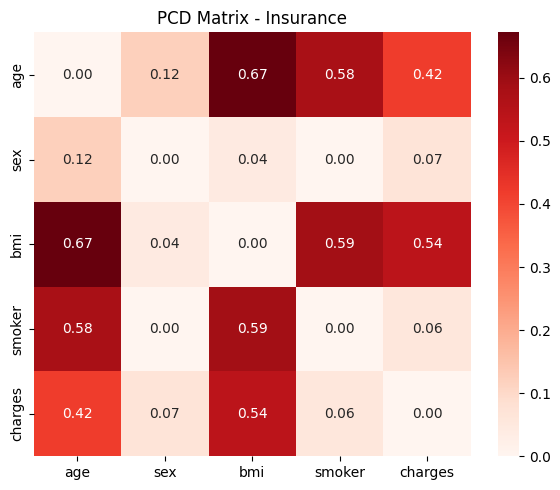

In [28]:
from sklearn.preprocessing import LabelEncoder

def encode_df(df):
    df_enc = df.copy()
    le = LabelEncoder()
    for col in df_enc.columns:
        if df_enc[col].dtype == object:
            df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    return df_enc

real_enc = encode_df(real)
synt_enc = encode_df(synt)

corr_real = real_enc.corr()
corr_synt = synt_enc.corr()

pcd = np.abs(corr_real - corr_synt).values
pcd_score = np.nanmean(pcd)

print("=== PCD (semakin kecil semakin mirip, ideal < 0.1) ===\n")
status = "✅" if pcd_score < 0.1 else "⚠️"
print(f"  {status} PCD Score : {pcd_score:.4f}")

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(np.abs(corr_real - corr_synt),
            annot=True, fmt=".2f", cmap="Reds",
            xticklabels=corr_real.columns,
            yticklabels=corr_real.columns)
plt.title("PCD Matrix - Insurance")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dataset GPT 4/pcd_insurance.png', dpi=150)
plt.show()

In [29]:
print("=" * 45)
print("  REKAP EVALUASI FIDELITY - INSURANCE")
print("=" * 45)
print(f"\n  JSD rata-rata  : {jsd_mean:.4f}")
print(f"  WD rata-rata   : {wd_mean:.4f}")
print(f"  PCD Score      : {pcd_score:.4f}")
print("\n  Interpretasi:")
print("  JSD & PCD < 0.1 → distribusi dan korelasi sangat mirip data asli")
print("  WD → semakin kecil semakin baik, tergantung skala kolom")

  REKAP EVALUASI FIDELITY - INSURANCE

  JSD rata-rata  : 0.1700
  WD rata-rata   : 1228.9296
  PCD Score      : 0.2472

  Interpretasi:
  JSD & PCD < 0.1 → distribusi dan korelasi sangat mirip data asli
  WD → semakin kecil semakin baik, tergantung skala kolom


##18.2 Evaluasi Sick

In [30]:
real_sick = sickfinal.copy()
synt_sick = pd.read_csv('/content/drive/MyDrive/Dataset GPT 4/sick_synthetic_20pct.csv')

print(f"Real : {real_sick.shape}")
print(f"Synt : {synt_sick.shape}")

Real : (3709, 27)
Synt : (667, 27)


###18.2.1 JSD (Jensen-Shannon Divergence)

In [31]:
cat_cols_sick = [
    'sex', 'on_thyroxine', 'query_on_thyroxine', 'on_antithyroid_medication',
    'sick', 'pregnant', 'thyroid_surgery', 'I131_treatment',
    'query_hypothyroid', 'query_hyperthyroid', 'lithium', 'goitre',
    'tumor', 'hypopituitary', 'psych',
    'TSH_measured', 'T3_measured', 'TT4_measured', 'T4U_measured', 'FTI_measured',
    'Class'
]
num_cols_sick = ['age', 'TSH', 'T3', 'TT4', 'T4U', 'FTI']

jsd_results_sick = {}

for col in cat_cols_sick:
    score = compute_jsd(real_sick, synt_sick, col)
    jsd_results_sick[col] = score

for col in num_cols_sick:
    bins = np.histogram_bin_edges(pd.concat([real_sick[col], synt_sick[col]]), bins=20)
    p, _ = np.histogram(real_sick[col], bins=bins, density=True)
    q, _ = np.histogram(synt_sick[col], bins=bins, density=True)
    p = p + 1e-10
    q = q + 1e-10
    score = jensenshannon(p / p.sum(), q / q.sum())
    jsd_results_sick[col] = score

jsd_mean_sick = np.mean(list(jsd_results_sick.values()))

print("Jensen-Shannon Divergence (ideal < 0.1)\n")
print(f"  {'Column':<30} {'JSD':>8}  {'Note'}")
print(f"  {'-'*50}")
for col, score in jsd_results_sick.items():
    if score < 0.1:
        note = "low"
    elif score < 0.2:
        note = "moderate"
    else:
        note = "high"
    print(f"  {col:<30} {score:>8.4f}  {note}")
print(f"  {'-'*50}")
print(f"  {'Mean':<30} {jsd_mean_sick:>8.4f}")

Jensen-Shannon Divergence (ideal < 0.1)

  Column                              JSD  Note
  --------------------------------------------------
  sex                              0.0433  low
  on_thyroxine                     0.0206  low
  query_on_thyroxine               0.0527  low
  on_antithyroid_medication        0.0628  low
  sick                             0.0676  low
  pregnant                         0.0368  low
  thyroid_surgery                  0.0706  low
  I131_treatment                   0.0745  low
  query_hypothyroid                0.0234  low
  query_hyperthyroid               0.1190  moderate
  lithium                          0.0410  low
  goitre                           0.0565  low
  tumor                            0.0952  low
  hypopituitary                    0.0097  low
  psych                            0.1323  moderate
  TSH_measured                     0.1720  moderate
  T3_measured                      0.2242  high
  TT4_measured                     0.1267  

###18.2.2 WD (Wasserstein Distance)

In [32]:
wd_results_sick = {}

for col in num_cols_sick:
    score = wasserstein_distance(real_sick[col], synt_sick[col])
    wd_results_sick[col] = score

wd_mean_sick = np.mean(list(wd_results_sick.values()))

thresholds_sick = {col: real_sick[col].std() * 0.1 for col in num_cols_sick}

print("Wasserstein Distance (semakin kecil semakin mirip)\n")
print(f"  {'Column':<15} {'WD':>10}  {'Note'}")
print(f"  {'-'*40}")
for col, score in wd_results_sick.items():
    threshold = thresholds_sick[col]
    if score < threshold:
        note = "low"
    elif score < threshold * 3:
        note = "moderate"
    else:
        note = "high"
    print(f"  {col:<15} {score:>10.4f}  {note}")
print(f"  {'-'*40}")
print(f"  {'Mean':<15} {wd_mean_sick:>10.4f}")

Wasserstein Distance (semakin kecil semakin mirip)

  Column                  WD  Note
  ----------------------------------------
  age                 4.4596  moderate
  TSH                 3.4627  moderate
  T3                  0.2857  high
  TT4                14.9990  high
  T4U                 0.0585  high
  FTI                10.6856  high
  ----------------------------------------
  Mean                5.6585


###18.2.3 PCD (Pairwise Correlation Difference)

Pairwise Correlation Difference

  PCD Score            0.2659


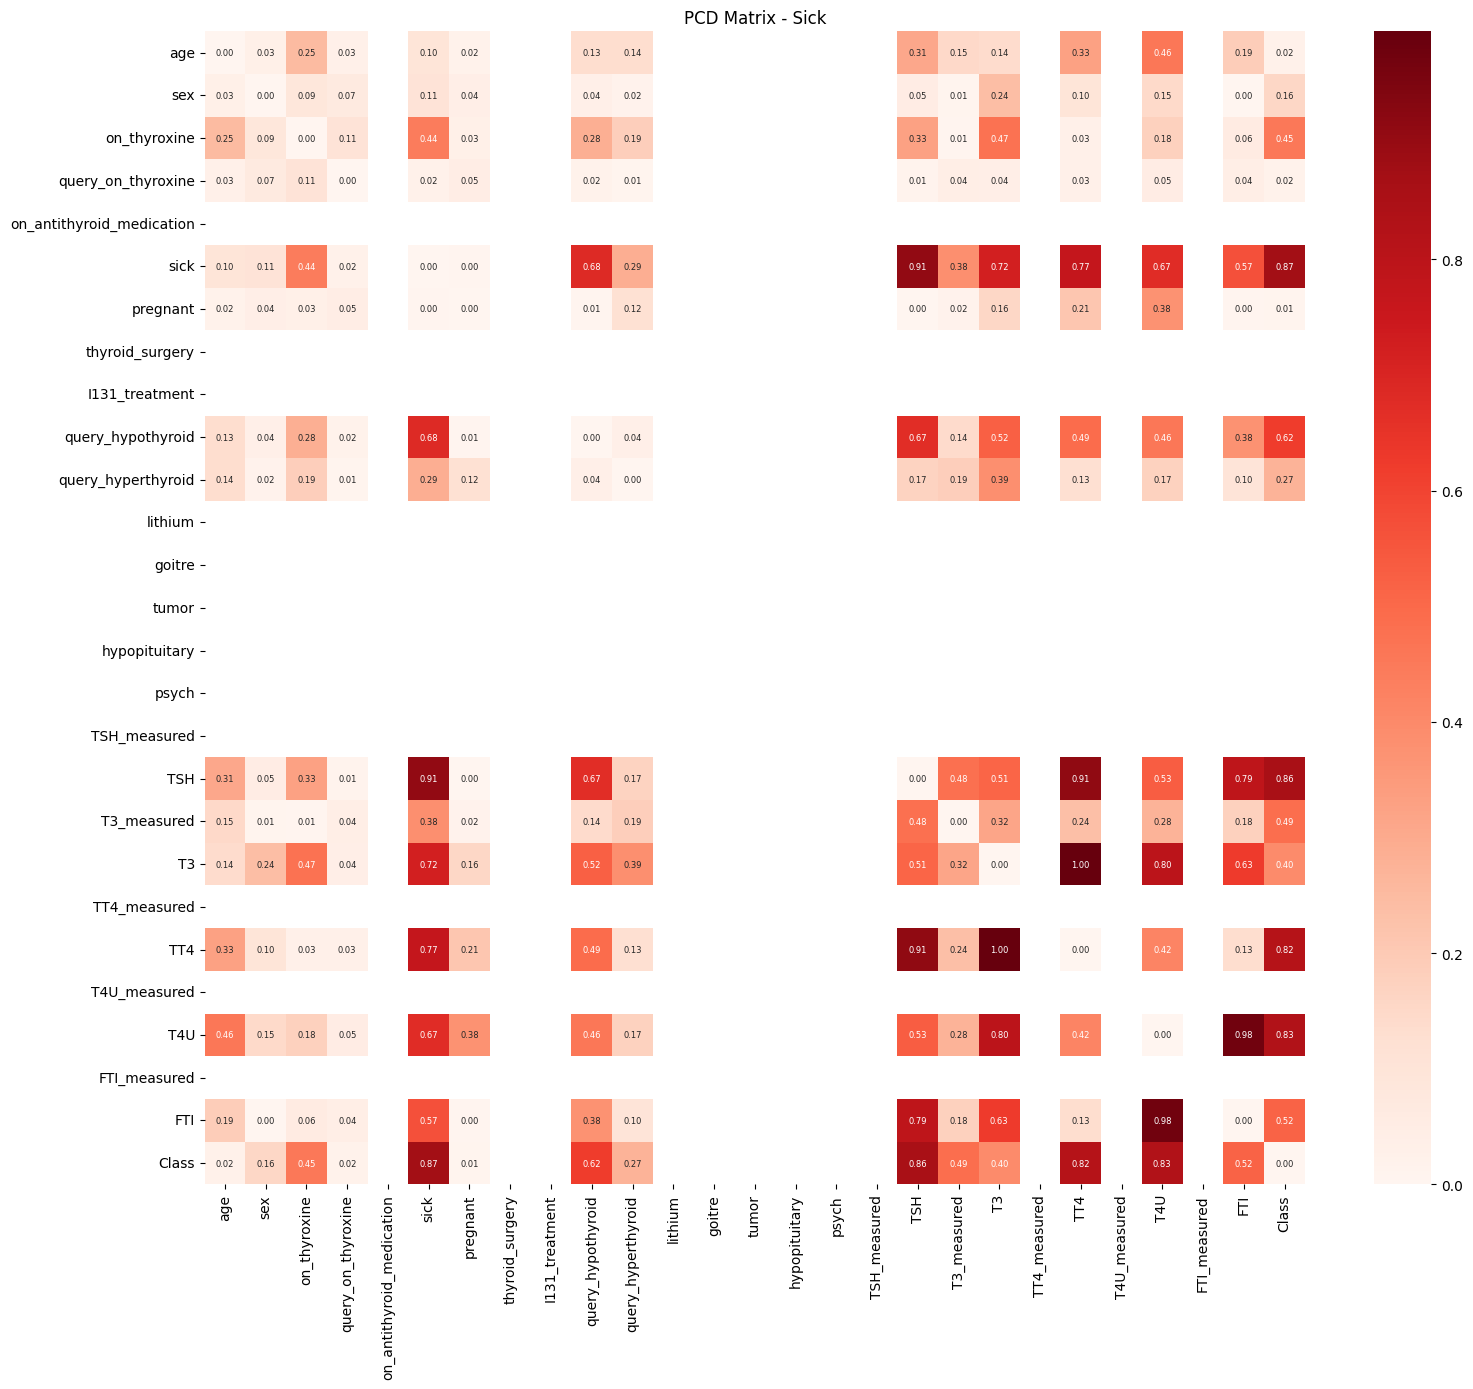

In [33]:
real_sick_enc = encode_df(real_sick)
synt_sick_enc = encode_df(synt_sick)

corr_real_sick = real_sick_enc.corr()
corr_synt_sick = synt_sick_enc.corr()

pcd_score_sick = np.nanmean(np.abs(corr_real_sick - corr_synt_sick).values)

print(f"Pairwise Correlation Difference\n")
print(f"  {'PCD Score':<20} {pcd_score_sick:.4f}")

plt.figure(figsize=(16, 14))
sns.heatmap(np.abs(corr_real_sick - corr_synt_sick),
            annot=True, fmt=".2f", cmap="Reds",
            xticklabels=corr_real_sick.columns,
            yticklabels=corr_real_sick.columns,
            annot_kws={"size": 6})
plt.title("PCD Matrix - Sick")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dataset GPT 4/pcd_sick.png', dpi=150)
plt.show()

In [34]:
print("=" * 45)
print("  REKAP EVALUASI FIDELITY - SICK")
print("=" * 45)
print(f"\n  {'Metric':<20} {'Score':>8}  {'Note'}")
print(f"  {'-'*40}")
print(f"  {'JSD Mean':<20} {jsd_mean_sick:>8.4f}  {'low' if jsd_mean_sick < 0.1 else 'moderate' if jsd_mean_sick < 0.2 else 'high'}")
print(f"  {'WD Mean':<20} {wd_mean_sick:>8.4f}")
print(f"  {'PCD Score':<20} {pcd_score_sick:>8.4f}  {'low' if pcd_score_sick < 0.1 else 'moderate' if pcd_score_sick < 0.2 else 'high'}")
print(f"  {'-'*40}")

  REKAP EVALUASI FIDELITY - SICK

  Metric                  Score  Note
  ----------------------------------------
  JSD Mean               0.1169  moderate
  WD Mean                5.6585
  PCD Score              0.2659  high
  ----------------------------------------


##18.3 Evaluasi Diabetic

In [35]:
real_diabetic = diabeticfinal.copy()
synt_diabetic = pd.read_csv(path_folder + 'diabetes_synthetic_20pct.csv')

print(f"Real : {real_diabetic.shape}")
print(f"Synt : {synt_diabetic.shape}")

Real : (101766, 38)
Synt : (16258, 38)


###18.3.1 JSD (Jensen-Shannon Divergence)

In [36]:
cat_cols_diabetic = [
    'race', 'sex', 'age', 'admission_type_id', 'discharge_disposition_id',
    'admission_source_id', 'metformin', 'repaglinide', 'nateglinide',
    'chlorpropamide', 'glimepiride', 'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'insulin',
    'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone', 'change',
    'diabetesMed', 'readmitted'
]
num_cols_diabetic = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_inpatient', 'number_diagnoses'
]

jsd_results_diabetic = {}

for col in cat_cols_diabetic:
    score = compute_jsd(real_diabetic, synt_diabetic, col)
    jsd_results_diabetic[col] = score

for col in num_cols_diabetic:
    bins = np.histogram_bin_edges(pd.concat([real_diabetic[col], synt_diabetic[col]]), bins=20)
    p, _ = np.histogram(real_diabetic[col], bins=bins, density=True)
    q, _ = np.histogram(synt_diabetic[col], bins=bins, density=True)
    p = p + 1e-10
    q = q + 1e-10
    score = jensenshannon(p / p.sum(), q / q.sum())
    jsd_results_diabetic[col] = score

jsd_mean_diabetic = np.mean(list(jsd_results_diabetic.values()))

print("Jensen-Shannon Divergence (ideal < 0.1)\n")
print(f"  {'Column':<30} {'JSD':>8}  {'Note'}")
print(f"  {'-'*50}")
for col, score in jsd_results_diabetic.items():
    if score < 0.1:
        note = "low"
    elif score < 0.2:
        note = "moderate"
    else:
        note = "high"
    print(f"  {col:<30} {score:>8.4f}  {note}")
print(f"  {'-'*50}")
print(f"  {'Mean':<30} {jsd_mean_diabetic:>8.4f}")

Jensen-Shannon Divergence (ideal < 0.1)

  Column                              JSD  Note
  --------------------------------------------------
  race                             0.1241  moderate
  sex                              0.0170  low
  age                              0.2183  high
  admission_type_id                0.2821  high
  discharge_disposition_id         0.3761  high
  admission_source_id              0.2161  high
  metformin                        0.3631  high
  repaglinide                      0.0714  low
  nateglinide                      0.0490  low
  chlorpropamide                   0.0171  low
  glimepiride                      0.0806  low
  glipizide                        0.1910  moderate
  glyburide                        0.1817  moderate
  tolbutamide                      0.0089  low
  pioglitazone                     0.1499  moderate
  rosiglitazone                    0.1482  moderate
  acarbose                         0.0324  low
  miglitol                   

###18.3.2 WD (Wasserstein Distance)

In [37]:
wd_results_diabetic = {}

for col in num_cols_diabetic:
    score = wasserstein_distance(real_diabetic[col], synt_diabetic[col])
    wd_results_diabetic[col] = score

wd_mean_diabetic = np.mean(list(wd_results_diabetic.values()))

thresholds_diabetic = {col: real_diabetic[col].std() * 0.1 for col in num_cols_diabetic}

print("Wasserstein Distance (semakin kecil semakin mirip)\n")
print(f"  {'Column':<25} {'WD':>10}  {'Note'}")
print(f"  {'-'*45}")
for col, score in wd_results_diabetic.items():
    threshold = thresholds_diabetic[col]
    if score < threshold:
        note = "low"
    elif score < threshold * 3:
        note = "moderate"
    else:
        note = "high"
    print(f"  {col:<25} {score:>10.4f}  {note}")
print(f"  {'-'*45}")
print(f"  {'Mean':<25} {wd_mean_diabetic:>10.4f}")

Wasserstein Distance (semakin kecil semakin mirip)

  Column                            WD  Note
  ---------------------------------------------
  time_in_hospital              1.2348  high
  num_lab_procedures            4.2417  moderate
  num_procedures                0.7064  high
  num_medications               2.5065  high
  number_inpatient              0.1877  moderate
  number_diagnoses              4.0970  high
  ---------------------------------------------
  Mean                          2.1624


###18.3.3 PCD (Pairwise Correlation Difference)

Pairwise Correlation Difference

  PCD Score            0.0925


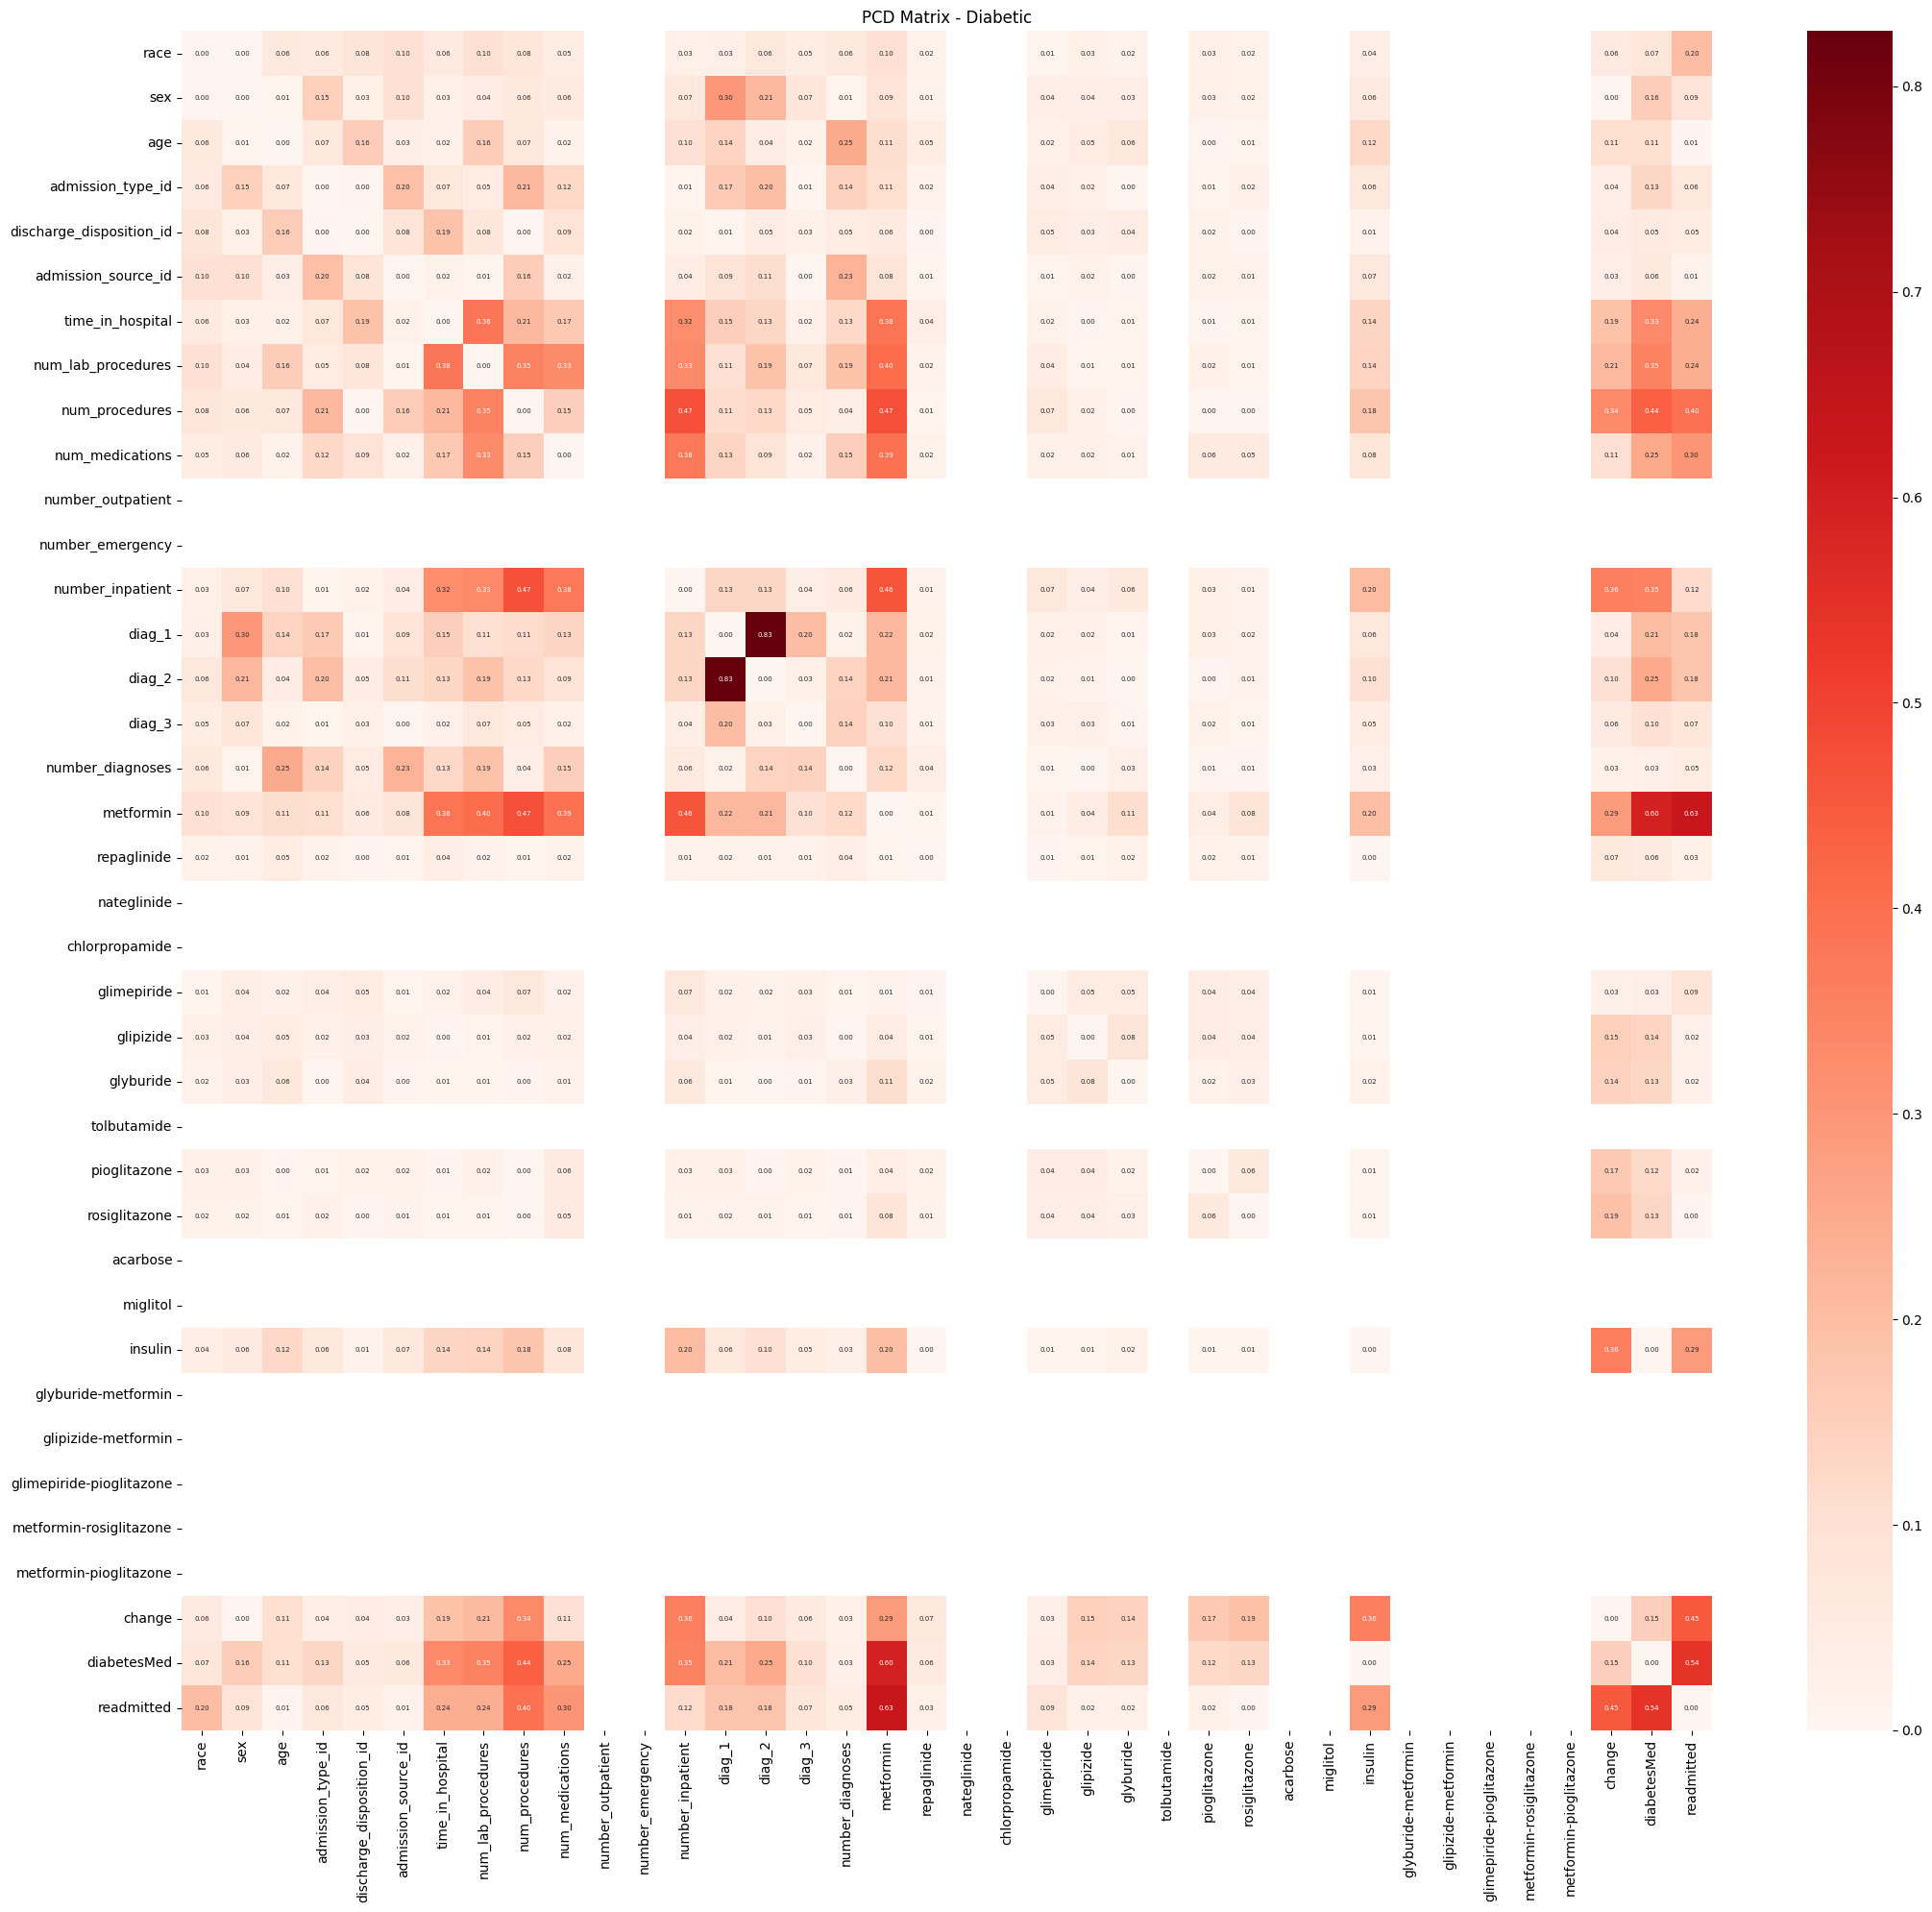

In [38]:
real_diabetic_enc = encode_df(real_diabetic)
synt_diabetic_enc = encode_df(synt_diabetic)

corr_real_diabetic = real_diabetic_enc.corr()
corr_synt_diabetic = synt_diabetic_enc.corr()

pcd_score_diabetic = np.nanmean(np.abs(corr_real_diabetic - corr_synt_diabetic).values)

print(f"Pairwise Correlation Difference\n")
print(f"  {'PCD Score':<20} {pcd_score_diabetic:.4f}")

plt.figure(figsize=(22, 20))
sns.heatmap(np.abs(corr_real_diabetic - corr_synt_diabetic),
            annot=True, fmt=".2f", cmap="Reds",
            xticklabels=corr_real_diabetic.columns,
            yticklabels=corr_real_diabetic.columns,
            annot_kws={"size": 5})
plt.title("PCD Matrix - Diabetic")
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dataset GPT 4/pcd_diabetic.png', dpi=150)
plt.show()

In [39]:
print("=" * 45)
print("  REKAP EVALUASI FIDELITY - DIABETIC")
print("=" * 45)
print(f"\n  {'Metric':<20} {'Score':>8}  {'Note'}")
print(f"  {'-'*40}")
print(f"  {'JSD Mean':<20} {jsd_mean_diabetic:>8.4f}  {'low' if jsd_mean_diabetic < 0.1 else 'moderate' if jsd_mean_diabetic < 0.2 else 'high'}")
print(f"  {'WD Mean':<20} {wd_mean_diabetic:>8.4f}")
print(f"  {'PCD Score':<20} {pcd_score_diabetic:>8.4f}  {'low' if pcd_score_diabetic < 0.1 else 'moderate' if pcd_score_diabetic < 0.2 else 'high'}")
print(f"  {'-'*40}")

  REKAP EVALUASI FIDELITY - DIABETIC

  Metric                  Score  Note
  ----------------------------------------
  JSD Mean               0.1681  moderate
  WD Mean                2.1624
  PCD Score              0.0925  low
  ----------------------------------------


#19.Evaluasi Utility

##19.1 Evaluasi Insurance

In [40]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

import xgboost as xgb


def encode_features(df):
    df_enc = df.copy()
    le = LabelEncoder()
    for col in df_enc.columns:
        if df_enc[col].dtype == object:
            df_enc[col] = le.fit_transform(df_enc[col].astype(str))
    return df_enc

def evaluate_model_clf(model, X_train, y_train, X_test, y_test, model_name, mode):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Mode": mode,
        "Model": model_name,
        "F1": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_pred_prob)
    }

print("Fungsi evaluasi classification siap.")

Fungsi evaluasi classification siap.


In [41]:
target = 'charges'

real_enc_ins = encode_features(real)
synt_enc_ins = encode_features(synt)

X_real = real_enc_ins.drop(columns=[target])
y_real = real_enc_ins[target]

X_synt = synt_enc_ins.drop(columns=[target])
y_synt = synt_enc_ins[target]

threshold = y_real.median()
y_real = (y_real > threshold).astype(int)
y_synt = (y_synt > threshold).astype(int)

X_train_real, X_test, y_train_real, y_test = train_test_split(
    X_real, y_real, test_size=0.2, random_state=42
)

print(f"Train real      : {X_train_real.shape}")
print(f"Train sintetis  : {X_synt.shape}")
print(f"Test            : {X_test.shape}")

Train real      : (1069, 4)
Train sintetis  : (267, 4)
Test            : (268, 4)


###19.1.1 TSTR & TRTR

In [42]:
models_ins = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
}

results_ins = []

for model_name, model in models_ins.items():
    results_ins.append(
        evaluate_model_clf(model, X_train_real, y_train_real, X_test, y_test, model_name, "TRTR")
    )

    results_ins.append(
        evaluate_model_clf(model, X_synt, y_synt, X_test, y_test, model_name, "TSTR")
    )

df_results_ins = pd.DataFrame(results_ins)

print("=" * 60)
print("  EVALUASI UTILITY - INSURANCE")
print("=" * 60)
print(f"  {'Mode':<6} {'Model':<16} {'F1-Score':>10} {'AUC-ROC':>10}")
print(f"  {'-'*50}")

for _, row in df_results_ins.iterrows():
    print(f"  {row['Mode']:<6} {row['Model']:<16} {row['F1']:>10.4f} {row['AUC-ROC']:>10.4f}")

print(f"  {'-'*50}")

df_results_ins.to_csv(path_folder + 'utility_insurance_clf.csv', index=False)
print("\nResults saved.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:32:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:32:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  EVALUASI UTILITY - INSURANCE
  Mode   Model              F1-Score    AUC-ROC
  --------------------------------------------------
  TRTR   Random Forest        0.8839     0.9383
  TSTR   Random Forest        0.6815     0.7621
  TRTR   XGBoost              0.8773     0.9381
  TSTR   XGBoost              0.7132     0.7633
  --------------------------------------------------

Results saved.


In [43]:
df_trtr = df_results_ins[df_results_ins['Mode'] == 'TRTR'].set_index('Model')
df_tstr = df_results_ins[df_results_ins['Mode'] == 'TSTR'].set_index('Model')

print("\nPerbandingan TRTR vs TSTR (Performance Gap)\n")
print(f"{'Model':<15} {'Metric':<10} {'TRTR':>8} {'TSTR':>8} {'Diff (Gap)':>12}")
print("-" * 60)

for model in df_trtr.index:
    trtr_f1 = df_trtr.loc[model, 'F1']
    tstr_f1 = df_tstr.loc[model, 'F1']
    diff_f1 = trtr_f1 - tstr_f1

    print(f"{model:<15} {'F1_Score':<10} {trtr_f1:>8.4f} {tstr_f1:>8.4f} {diff_f1:>12.4f}")

    trtr_auc = df_trtr.loc[model, 'AUC-ROC']
    tstr_auc = df_tstr.loc[model, 'AUC-ROC']
    diff_auc = trtr_auc - tstr_auc

    print(f"{model:<15} {'AUC_ROC':<10} {trtr_auc:>8.4f} {tstr_auc:>8.4f} {diff_auc:>12.4f}")

print("-" * 60)


Perbandingan TRTR vs TSTR (Performance Gap)

Model           Metric         TRTR     TSTR   Diff (Gap)
------------------------------------------------------------
Random Forest   F1_Score     0.8839   0.6815       0.2024
Random Forest   AUC_ROC      0.9383   0.7621       0.1762
XGBoost         F1_Score     0.8773   0.7132       0.1641
XGBoost         AUC_ROC      0.9381   0.7633       0.1748
------------------------------------------------------------


##19.2 Evaluasi Sick

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score
import xgboost as xgb

def evaluate_model_clf(model, X_train, y_train, X_test, y_test, model_name, mode):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    return {
        "Mode": mode,
        "Model": model_name,
        "F1-Score": f1_score(y_test, y_pred, pos_label=1),
        "AUC-ROC": roc_auc_score(y_test, y_pred_prob)
    }

In [45]:
target_sick = 'Class'

real_sick_enc2 = encode_features(real_sick)
synt_sick_enc2 = encode_features(synt_sick)

from sklearn.preprocessing import LabelEncoder
le_target = LabelEncoder()
le_target.fit(['negative', 'sick'])

real_sick_enc2[target_sick] = le_target.transform(real_sick[target_sick])
synt_sick_enc2[target_sick] = le_target.transform(synt_sick[target_sick])

X_real_sick = real_sick_enc2.drop(columns=[target_sick])
y_real_sick = real_sick_enc2[target_sick]

X_synt_sick = synt_sick_enc2.drop(columns=[target_sick])
y_synt_sick = synt_sick_enc2[target_sick]

from sklearn.model_selection import train_test_split
X_train_real_sick, X_test_sick, y_train_real_sick, y_test_sick = train_test_split(
    X_real_sick, y_real_sick, test_size=0.2, random_state=42, stratify=y_real_sick
)

print(f"Train real : {X_train_real_sick.shape}")
print(f"Train synt : {X_synt_sick.shape}")
print(f"Test       : {X_test_sick.shape}")

Train real : (2967, 26)
Train synt : (667, 26)
Test       : (742, 26)


###19.2.1 TSTR & TRTR

In [46]:
models_sick_util = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100,
        random_state=42,
        scale_pos_weight=(y_real_sick==0).sum()/(y_real_sick==1).sum(),
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0
    )
}

results_sick_util = []

for model_name, model in models_sick_util.items():

    results_sick_util.append(
        evaluate_model_clf(model, X_train_real_sick, y_train_real_sick, X_test_sick, y_test_sick, model_name, "TRTR")
    )

    results_sick_util.append(
        evaluate_model_clf(model, X_synt_sick, y_synt_sick, X_test_sick, y_test_sick, model_name, "TSTR")
    )

df_results_sick_util = pd.DataFrame(results_sick_util)

print("=" * 60)
print("  EVALUASI UTILITY - SICK")
print("=" * 60)
print(f"  {'Mode':<6} {'Model':<16} {'F1-Score':>10} {'AUC-ROC':>10}")
print(f"  {'-'*50}")

for _, row in df_results_sick_util.iterrows():
    print(f"  {row['Mode']:<6} {row['Model']:<16} {row['F1-Score']:>10.4f} {row['AUC-ROC']:>10.4f}")

print(f"  {'-'*50}")

df_results_sick_util.to_csv(path_folder + 'utility_sick_clf.csv', index=False)
print("\nResults saved.")

  EVALUASI UTILITY - SICK
  Mode   Model              F1-Score    AUC-ROC
  --------------------------------------------------
  TRTR   Random Forest        0.8049     0.9952
  TSTR   Random Forest        0.0952     0.8758
  TRTR   XGBoost              0.9032     0.9968
  TSTR   XGBoost              0.1468     0.8381
  --------------------------------------------------

Results saved.


In [47]:
df_trtr = df_results_sick_util[df_results_sick_util['Mode'] == 'TRTR'].set_index('Model')
df_tstr = df_results_sick_util[df_results_sick_util['Mode'] == 'TSTR'].set_index('Model')

print("\nPerbandingan TRTR vs TSTR (Performance Gap)\n")

print(f"{'Model':<15} {'Metric':<10} {'TRTR':>8} {'TSTR':>8} {'Diff (Gap)':>12}")
print("-" * 65)

for model in df_trtr.index:
    trtr_f1 = df_trtr.loc[model, 'F1-Score']
    tstr_f1 = df_tstr.loc[model, 'F1-Score']
    diff_f1 = trtr_f1 - tstr_f1

    print(f"{model:<15} {'F1_Score':<10} {trtr_f1:>8.4f} {tstr_f1:>8.4f} {diff_f1:>+12.4f}")
    trtr_auc = df_trtr.loc[model, 'AUC-ROC']
    tstr_auc = df_tstr.loc[model, 'AUC-ROC']
    diff_auc = trtr_auc - tstr_auc

    print(f"{model:<15} {'AUC_ROC':<10} {trtr_auc:>8.4f} {tstr_auc:>8.4f} {diff_auc:>+12.4f}")

print("-" * 65)


Perbandingan TRTR vs TSTR (Performance Gap)

Model           Metric         TRTR     TSTR   Diff (Gap)
-----------------------------------------------------------------
Random Forest   F1_Score     0.8049   0.0952      +0.7096
Random Forest   AUC_ROC      0.9952   0.8758      +0.1193
XGBoost         F1_Score     0.9032   0.1468      +0.7564
XGBoost         AUC_ROC      0.9968   0.8381      +0.1587
-----------------------------------------------------------------


##19.3 Evaluasi Diabetic

In [48]:
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

def evaluate_model_multi(model, X_train, y_train, X_test, y_test, model_name, mode, classes):
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)

    f1 = f1_score(y_test, y_pred, average='weighted')

    y_test_bin = label_binarize(y_test, classes=classes)
    auc = roc_auc_score(y_test_bin, y_pred_prob, multi_class='ovr', average='weighted')

    return {
        "Mode": mode,
        "Model": model_name,
        "F1-Score": f1,
        "AUC-ROC": auc
    }

In [49]:
target_diabetic = 'readmitted'

real_diabetic['readmitted'] = real_diabetic['readmitted'].replace({'No': 'NO'})
synt_diabetic['readmitted'] = synt_diabetic['readmitted'].replace({'No': 'NO'})

real_diabetic_enc2 = encode_features(real_diabetic)
synt_diabetic_enc2 = encode_features(synt_diabetic)

from sklearn.preprocessing import LabelEncoder
le_target_diabetic = LabelEncoder()
le_target_diabetic.fit(real_diabetic[target_diabetic])

real_diabetic_enc2[target_diabetic] = le_target_diabetic.transform(real_diabetic[target_diabetic])
synt_diabetic_enc2[target_diabetic] = le_target_diabetic.transform(synt_diabetic[target_diabetic])

classes_diabetic = list(range(len(le_target_diabetic.classes_)))

X_real_diab = real_diabetic_enc2.drop(columns=[target_diabetic])
y_real_diab = real_diabetic_enc2[target_diabetic]

X_synt_diab = synt_diabetic_enc2.drop(columns=[target_diabetic])
y_synt_diab = synt_diabetic_enc2[target_diabetic]

from sklearn.model_selection import train_test_split
X_train_real_diab, X_test_diab, y_train_real_diab, y_test_diab = train_test_split(
    X_real_diab, y_real_diab, test_size=0.2, random_state=42, stratify=y_real_diab
)

print(f"Train real : {X_train_real_diab.shape}")
print(f"Train synt : {X_synt_diab.shape}")
print(f"Test       : {X_test_diab.shape}")

Train real : (81412, 37)
Train synt : (16258, 37)
Test       : (20354, 37)


###19.3.1 TSTR & TRTR

In [50]:
models_diab_util = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=100,
        random_state=42,
        eval_metric='mlogloss',
        use_label_encoder=False,
        verbosity=0
    )
}

results_diab_util = []

for model_name, model in models_diab_util.items():
    results_diab_util.append(
        evaluate_model_multi(
            model,
            X_train_real_diab, y_train_real_diab,
            X_test_diab, y_test_diab,
            model_name, "TRTR",
            classes_diabetic
        )
    )
    results_diab_util.append(
        evaluate_model_multi(
            model,
            X_synt_diab, y_synt_diab,
            X_test_diab, y_test_diab,
            model_name, "TSTR",
            classes_diabetic
        )
    )

df_results_diab_util = pd.DataFrame(results_diab_util)

print("=" * 60)
print("  EVALUASI UTILITY - DIABETIC")
print("=" * 60)
print(f"  {'Mode':<6} {'Model':<16} {'F1-Score':>10} {'AUC-ROC':>10}")
print(f"  {'-'*50}")

for _, row in df_results_diab_util.iterrows():
    print(f"  {row['Mode']:<6} {row['Model']:<16} {row['F1-Score']:>10.4f} {row['AUC-ROC']:>10.4f}")

print(f"  {'-'*50}")

df_results_diab_util.to_csv(path_folder + 'utility_diabetic_clf.csv', index=False)
print("\nResults saved.")

  EVALUASI UTILITY - DIABETIC
  Mode   Model              F1-Score    AUC-ROC
  --------------------------------------------------
  TRTR   Random Forest        0.5261     0.6582
  TSTR   Random Forest        0.4024     0.5345
  TRTR   XGBoost              0.5458     0.6819
  TSTR   XGBoost              0.3049     0.5238
  --------------------------------------------------

Results saved.


In [51]:
df_trtr = df_results_diab_util[df_results_diab_util['Mode'] == 'TRTR'].set_index('Model')
df_tstr = df_results_diab_util[df_results_diab_util['Mode'] == 'TSTR'].set_index('Model')

print("\nPerbandingan TRTR vs TSTR (Performance Gap)\n")

print(f"{'Model':<15} {'Metric':<10} {'TRTR':>8} {'TSTR':>8} {'Diff (Gap)':>12}")
print("-" * 65)

for model in df_trtr.index:
    trtr_f1 = df_trtr.loc[model, 'F1-Score']
    tstr_f1 = df_tstr.loc[model, 'F1-Score']
    diff_f1 = trtr_f1 - tstr_f1

    print(f"{model:<15} {'F1_Score':<10} {trtr_f1:>8.4f} {tstr_f1:>8.4f} {diff_f1:>+12.4f}")
    trtr_auc = df_trtr.loc[model, 'AUC-ROC']
    tstr_auc = df_tstr.loc[model, 'AUC-ROC']
    diff_auc = trtr_auc - tstr_auc

    print(f"{model:<15} {'AUC_ROC':<10} {trtr_auc:>8.4f} {tstr_auc:>8.4f} {diff_auc:>+12.4f}")

print("-" * 65)


Perbandingan TRTR vs TSTR (Performance Gap)

Model           Metric         TRTR     TSTR   Diff (Gap)
-----------------------------------------------------------------
Random Forest   F1_Score     0.5261   0.4024      +0.1237
Random Forest   AUC_ROC      0.6582   0.5345      +0.1237
XGBoost         F1_Score     0.5458   0.3049      +0.2409
XGBoost         AUC_ROC      0.6819   0.5238      +0.1581
-----------------------------------------------------------------


#20.Evaluasi Quality

##20.1 Evaluasi Insurance

###20.1.1 Schema Validity

In [52]:
def check_schema_validity(df, schema):
    results = {}
    total_cells  = 0
    valid_cells  = 0

    for col, rules in schema['columns'].items():
        if col not in df.columns:
            continue
        if rules.get('type') == 'categorical' and 'allowed_values' in rules:
            allowed  = [str(v) for v in rules['allowed_values']]
            col_vals = df[col].astype(str)
            valid    = col_vals.isin(allowed).sum()
            total    = len(col_vals)
            invalid  = total - valid
            results[col] = {
                'total'  : total,
                'valid'  : valid,
                'invalid': invalid,
                'pct'    : round(valid / total * 100, 2)
            }
            total_cells += total
            valid_cells += valid

    overall = round(valid_cells / total_cells * 100, 2) if total_cells > 0 else 0

    print("Schema Validity\n")
    print(f"  {'Column':<15} {'Valid':>8} {'Invalid':>8} {'Pct':>8}")
    print(f"  {'-'*45}")
    for col, res in results.items():
        print(f"  {col:<15} {res['valid']:>8} {res['invalid']:>8} {res['pct']:>7.2f}%")
    print(f"  {'-'*45}")
    print(f"  {'Overall':<15} {valid_cells:>8} {total_cells - valid_cells:>8} {overall:>7.2f}%")

    return overall

schema_validity_insurance = check_schema_validity(synt, insurance_schema)

Schema Validity

  Column             Valid  Invalid      Pct
  ---------------------------------------------
  sex                  267        0  100.00%
  smoker               267        0  100.00%
  ---------------------------------------------
  Overall              534        0  100.00%


###20.1.2 Domain Constraints

In [53]:
def check_domain_constraints(df, schema):
    results     = {}
    total_cells = 0
    valid_cells = 0

    for col, rules in schema['columns'].items():
        if col not in df.columns:
            continue
        if rules.get('type') in ['integer', 'float'] and 'min' in rules and 'max' in rules:
            col_vals = pd.to_numeric(df[col], errors='coerce')
            valid    = col_vals.between(rules['min'], rules['max']).sum()
            total    = len(col_vals)
            invalid  = total - valid
            results[col] = {
                'min'    : rules['min'],
                'max'    : rules['max'],
                'mean'   : round(float(col_vals.mean()), 2),
                'std'    : round(float(col_vals.std()),  2),
                'valid'  : valid,
                'invalid': invalid,
                'pct'    : round(valid / total * 100, 2)
            }
            total_cells += total
            valid_cells += valid

    overall = round(valid_cells / total_cells * 100, 2) if total_cells > 0 else 0

    print("Domain Constraints (Range + Mean ± 3STD)\n")
    print(f"  {'Column':<15} {'Min':>8} {'Max':>8} {'Mean':>8} {'STD':>8} {'Valid':>8} {'Invalid':>8} {'Pct':>8}")
    print(f"  {'-'*82}")
    for col, res in results.items():
        print(f"  {col:<15} {res['min']:>8} {res['max']:>8} {res['mean']:>8} {res['std']:>8} {res['valid']:>8} {res['invalid']:>8} {res['pct']:>7.2f}%")
    print(f"  {'-'*82}")
    print(f"  {'Overall':<15} {'':>8} {'':>8} {'':>8} {'':>8} {valid_cells:>8} {total_cells - valid_cells:>8} {overall:>7.2f}%")

    return overall

domain_validity_insurance = check_domain_constraints(synt, insurance_schema)

Domain Constraints (Range + Mean ± 3STD)

  Column               Min      Max     Mean      STD    Valid  Invalid      Pct
  ----------------------------------------------------------------------------------
  age                   18       64    40.46    12.44      267        0  100.00%
  bmi                15.96    53.13    29.86     4.09      267        0  100.00%
  charges          1121.87 63770.43 16943.19 15457.79      266        1   99.63%
  ----------------------------------------------------------------------------------
  Overall                                                  800        1   99.88%


###20.1.3 Logical Consistency

In [54]:
def check_logical_consistency_insurance(df):

    CHARGES_LOW   = 4_500
    CHARGES_HIGH  = 25_000
    AGE_MUDA      = 29
    AGE_TUA       = 52
    BMI_NORMAL_HI = 25.0
    BMI_OW_HI     = 30.0

    def valid_high(mask):
        sub = df[mask]
        return (sub['charges'] > CHARGES_HIGH).sum(), len(sub)

    def valid_low(mask):
        sub = df[mask]
        return (sub['charges'] < CHARGES_LOW).sum(), len(sub)

    def passes_high(mask):
        return df[mask]['charges'].mean() > CHARGES_HIGH if mask.sum() > 0 else False

    def passes_low(mask):
        return df[mask]['charges'].mean() < CHARGES_LOW if mask.sum() > 0 else False

    smoker      = df['smoker'] == 'Yes'
    non_smoker  = df['smoker'] == 'No'
    bmi_high    = df['bmi']   >= BMI_OW_HI
    bmi_ow      = df['bmi'].between(25.0, BMI_OW_HI - 0.001)
    bmi_norm    = df['bmi']    < BMI_NORMAL_HI
    bmi_ok      = df['bmi']    < BMI_OW_HI
    age_muda    = df['age']    < AGE_MUDA
    age_dws     = df['age'].between(AGE_MUDA, AGE_TUA - 1)
    age_tua     = df['age']   >= AGE_TUA
    age_non_tua = df['age']    < AGE_TUA

    mean_muda = df[age_muda]['charges'].mean()
    mean_dws  = df[age_dws ]['charges'].mean()
    mean_tua  = df[age_tua ]['charges'].mean()

    rules_data = [
        ('A', 'A1',  'Smoker Yes + BMI tinggi (>=30) -> Charges tinggi (>$25K)',                smoker & bmi_high,            'high'),
        ('A', 'A2',  'Smoker Yes + Age tua (>=52) -> Charges tinggi (>$25K)',                   smoker & age_tua,             'high'),
        ('A', 'A3',  'Age tua (>=52) + BMI tinggi (>=30) -> Charges tinggi (>$25K)',            age_tua & bmi_high,           'high'),
        ('A', 'A4',  'Smoker Yes + BMI tinggi + Age tua -> Charges tinggi (>$25K)',             smoker & bmi_high & age_tua,  'high'),
        ('A', 'A5',  'Smoker Yes + BMI normal (<25) + Age tua -> Charges tinggi (>$25K)',       smoker & bmi_norm & age_tua,  'high'),
        ('A', 'A6a', 'BMI tinggi (>=30) + Age muda (<29) -> Charges tinggi (>$25K)',            bmi_high & age_muda,          'high'),
        ('A', 'A6b', 'BMI tinggi (>=30) + Age dewasa (29-51) -> Charges tinggi (>$25K)',        bmi_high & age_dws,           'high'),
        ('A', 'A6c', 'BMI tinggi (>=30) + Age tua (>=52) -> Charges tinggi (>$25K)',            bmi_high & age_tua,           'high'),
        ('A', 'A7',  'Age tua (>=52) -> Charges naik (muda < dewasa < tua)',                    None,                         'mono'),
        ('A', 'A8',  'Smoker Yes -> Charges tinggi (>$25K)',                                    smoker,                       'high'),
        ('B', 'B1',  'Non-smoker + BMI normal (<25) + Age muda (<29) -> Charges rendah (<$4.5K)',          non_smoker & bmi_norm & age_muda,   'low'),
        ('B', 'B2',  'Non-smoker + BMI normal (<25) + Age dewasa (29-51) -> Charges rendah (<$4.5K)',      non_smoker & bmi_norm & age_dws,    'low'),
        ('B', 'B3',  'Non-smoker + BMI normal (<25) semua usia -> Charges rendah (<$4.5K)',               non_smoker & bmi_norm,              'low'),
        ('B', 'B4',  'Non-smoker + BMI overweight (25-29.9) + Age muda (<29) -> Charges rendah (<$4.5K)', non_smoker & bmi_ow & age_muda,     'low'),
        ('B', 'B5',  'Non-smoker + BMI <30 + Age muda (<29) -> Charges rendah (<$4.5K)',                  non_smoker & bmi_ok & age_muda,     'low'),
        ('B', 'B6',  'Non-smoker + BMI normal (<25) + Age non-tua (<52) -> Charges rendah (<$4.5K)',      non_smoker & bmi_norm & age_non_tua,'low'),
    ]

    rows = []
    for section, tag, label, mask, direction in rules_data:
        if direction == 'high':
            v, t   = valid_high(mask)
            passed = passes_high(mask)
            detail = f"{v}/{t} valid (charges >$25K)"
        elif direction == 'low':
            v, t   = valid_low(mask)
            passed = passes_low(mask)
            detail = f"{v}/{t} valid (charges <$4.5K)"
        else:
            passed = (mean_tua > mean_dws > mean_muda)
            detail = f"muda=${mean_muda:,.0f} | dewasa=${mean_dws:,.0f} | tua=${mean_tua:,.0f}"
        rows.append((section, tag, label, passed, detail))

    W_RULE   = max(len(r[2]) for r in rows)
    W_STATUS = 6
    W_DETAIL = max(len(r[4]) for r in rows)

    total_w  = W_RULE + 4 + W_STATUS + 4 + W_DETAIL
    div      = "-" * (total_w + 2)

    print()
    print(div)
    print(f"  {'Rule':<{W_RULE}}    {'Status':^{W_STATUS}}    {'Detail':<{W_DETAIL}}")
    print(div)

    prev_section = None
    passed_total = 0
    for section, tag, label, passed, detail in rows:
        if prev_section and section != prev_section:
            print(div)
        prev_section = section
        status = "pass" if passed else "fail"
        if passed:
            passed_total += 1
        print(f"  {label:<{W_RULE}}    {status:^{W_STATUS}}    {detail:<{W_DETAIL}}")

    n_rules = len(rows)
    pct     = round(passed_total / n_rules * 100, 2)
    print(div)
    print(f"  {passed_total}/{n_rules} rules passed ({pct:.2f}%)")
    print(div)
    print()

    return pct


logical_score_insurance = check_logical_consistency_insurance(synt)


-------------------------------------------------------------------------------------------------------------------------------------------
  Rule                                                                                 Status    Detail                                    
-------------------------------------------------------------------------------------------------------------------------------------------
  Smoker Yes + BMI tinggi (>=30) -> Charges tinggi (>$25K)                              pass     61/80 valid (charges >$25K)               
  Smoker Yes + Age tua (>=52) -> Charges tinggi (>$25K)                                 pass     41/51 valid (charges >$25K)               
  Age tua (>=52) + BMI tinggi (>=30) -> Charges tinggi (>$25K)                          pass     41/66 valid (charges >$25K)               
  Smoker Yes + BMI tinggi + Age tua -> Charges tinggi (>$25K)                           pass     41/51 valid (charges >$25K)               
  Smoker Yes + BMI 

###20.1.4 Quality Score

In [55]:
def compute_quality_score(schema_score, domain_score, logical_score,
                           w_schema=0.35, w_domain=0.35, w_logical=0.30):
    score = (w_schema  * schema_score +
             w_domain  * domain_score +
             w_logical * logical_score)
    return round(score, 2)

quality_score_insurance = compute_quality_score(
    schema_validity_insurance,
    domain_validity_insurance,
    logical_score_insurance
)

print("=" * 50)
print("  REKAP EVALUASI QUALITY - INSURANCE")
print("=" * 50)
print(f"\n  {'Metric':<30} {'Score':>8}")
print(f"  {'-'*40}")
print(f"  {'Schema Validity':<30} {schema_validity_insurance:>7.2f}%")
print(f"  {'Domain Constraints':<30} {domain_validity_insurance:>7.2f}%")
print(f"  {'Logical Consistency':<30} {logical_score_insurance:>7.2f}%")
print(f"  {'-'*40}")
print(f"  {'Quality Score':<30} {quality_score_insurance:>7.2f}%")

import pandas as pd
pd.DataFrame([{
    'dataset'           : 'insurance',
    'schema_validity'   : schema_validity_insurance,
    'domain_constraints': domain_validity_insurance,
    'logical_consistency': logical_score_insurance,
    'quality_score'     : quality_score_insurance
}]).to_csv('/content/drive/MyDrive/Dataset GPT 4/quality_insurance.csv', index=False)
print("\n  Results saved.")

  REKAP EVALUASI QUALITY - INSURANCE

  Metric                            Score
  ----------------------------------------
  Schema Validity                 100.00%
  Domain Constraints               99.88%
  Logical Consistency              75.00%
  ----------------------------------------
  Quality Score                    92.46%

  Results saved.


##20.2 Evaluasi Sick

###20.2.1 Schema Validity

In [56]:
def check_schema_validity(df, schema):
    results = {}
    total_cells = 0
    valid_cells = 0

    for col, rules in schema['columns'].items():
        if col not in df.columns:
            continue

        col_vals = df[col]
        total = len(col_vals)

        if rules.get('type') == 'categorical':
            allowed = [str(v) for v in rules.get('allowed_values', [])]
            valid_mask = col_vals.astype(str).isin(allowed)

        elif rules.get('type') in ['numerical', 'integer', 'float']:
            col_vals_num = pd.to_numeric(col_vals, errors='coerce')

            valid_mask = col_vals_num.notnull()

            if 'min' in rules:
                valid_mask &= col_vals_num >= rules['min']
            if 'max' in rules:
                valid_mask &= col_vals_num <= rules['max']

        else:
            continue

        valid_count = valid_mask.sum()
        invalid = total - valid_count

        results[col] = {
            'valid': int(valid_count),
            'invalid': int(invalid),
            'pct': round(valid_count / total * 100, 2)
        }

        total_cells += total
        valid_cells += valid_count

    overall = round(valid_cells / total_cells * 100, 2) if total_cells > 0 else 0

    print("Schema Validity\n")
    print(f"{'Column':<30} {'Valid':>8} {'Invalid':>8} {'Pct':>8}")
    print("-"*60)

    for col, res in results.items():
        print(f"{col:<30} {res['valid']:>8} {res['invalid']:>8} {res['pct']:>7.2f}%")

    print("-"*60)
    print(f"{'Overall':<30} {valid_cells:>8} {total_cells - valid_cells:>8} {overall:>7.2f}%")

    return overall

schema_validity_sick = check_schema_validity(synt_sick, sick_schema)

Schema Validity

Column                            Valid  Invalid      Pct
------------------------------------------------------------
age                                 667        0  100.00%
sex                                 667        0  100.00%
on_thyroxine                        667        0  100.00%
query_on_thyroxine                  667        0  100.00%
on_antithyroid_medication           667        0  100.00%
sick                                667        0  100.00%
pregnant                            667        0  100.00%
thyroid_surgery                     667        0  100.00%
I131_treatment                      667        0  100.00%
query_hypothyroid                   667        0  100.00%
query_hyperthyroid                  667        0  100.00%
lithium                             667        0  100.00%
goitre                              667        0  100.00%
tumor                               667        0  100.00%
hypopituitary                       667        0  10

###20.2.2 Domain Constraints

In [57]:
def check_domain_constraints(df, schema):
    results = {}
    total_cells = 0
    valid_cells = 0

    for col, rules in schema['columns'].items():
        if col not in df.columns:
            continue

        if rules.get('type') in ['integer', 'float', 'numerical']:
            col_vals = pd.to_numeric(df[col], errors='coerce')
            total = len(col_vals)

            valid_mask = col_vals.notnull()

            if 'min' in rules:
                valid_mask &= col_vals >= rules['min']
            if 'max' in rules:
                valid_mask &= col_vals <= rules['max']

            valid_count = valid_mask.sum()
            invalid = total - valid_count

            mean_val = float(col_vals.mean())
            std_val = float(col_vals.std())

            results[col] = {
                'min': rules.get('min', '-'),
                'max': rules.get('max', '-'),
                'mean': round(mean_val, 2),
                'std': round(std_val, 2),
                'valid': int(valid_count),
                'invalid': int(invalid),
                'pct': round(valid_count / total * 100, 2)
            }

            total_cells += total
            valid_cells += valid_count

    overall = round(valid_cells / total_cells * 100, 2) if total_cells > 0 else 0

    print("Domain Constraints (Range Check)\n")
    print(f"{'Column':<20} {'Min':>8} {'Max':>8} {'Mean':>8} {'STD':>8} {'Valid':>8} {'Invalid':>8} {'Pct':>8}")
    print("-"*90)

    for col, res in results.items():
        print(f"{col:<20} {res['min']:>8} {res['max']:>8} {res['mean']:>8} {res['std']:>8} {res['valid']:>8} {res['invalid']:>8} {res['pct']:>7.2f}%")

    print("-"*90)
    print(f"{'Overall':<20} {'':>8} {'':>8} {'':>8} {'':>8} {valid_cells:>8} {total_cells - valid_cells:>8} {overall:>7.2f}%")

    return overall

domain_validity_sick = check_domain_constraints(synt_sick, sick_schema)

Domain Constraints (Range Check)

Column                    Min      Max     Mean      STD    Valid  Invalid      Pct
------------------------------------------------------------------------------------------
age                         1      455    49.51    16.27      667        0  100.00%
TSH                     0.005      530     3.53     3.72      667        0  100.00%
T3                       0.05     10.6     2.15     0.52      667        0  100.00%
TT4                         2      430   122.25    31.35      667        0  100.00%
T4U                      0.25     2.32     1.04     0.14      667        0  100.00%
FTI                         2      395   112.34    18.86      667        0  100.00%
------------------------------------------------------------------------------------------
Overall                                                      4002        0  100.00%


###20.2.3 Logical Consistency

In [58]:
def check_logical_consistency_sick(df):
    results = {}

    # ── Reference ranges ──────────────────────────────────────────────────────
    TSH_LOW,  TSH_HIGH  = 0.4,  4.0
    T3_LOW,   T3_HIGH   = 1.2,  2.7
    TT4_LOW,  TT4_HIGH  = 60,   150
    T4U_LOW,  T4U_HIGH  = 0.8,  1.2
    FTI_LOW,  FTI_HIGH  = 70,   150

    N = len(df)
    overall_sick_rate = df['Class'].eq('sick').mean()

    def sick_rate(sub): return float(sub['Class'].eq('sick').mean())
    def sick_cnt(sub):  return int(sub['Class'].eq('sick').sum())

    def cat(val, lo, hi):
        if val < lo:  return 'low'
        if val <= hi: return 'normal'
        return 'high'

    def add(key, passed, detail):
        results[key] = {
            'passed': bool(passed) if passed is not None else None,
            'detail': detail
        }

    # ── Rules ────────────────────────────────────────────────────────────────

    # 1
    m1 = (df['TSH'] > TSH_HIGH) & ((df['T3'] < T3_LOW) | (df['TT4'] < TT4_LOW))
    g1 = df[m1]
    add('TSH↑ & (T3/TT4)↓ → hypothyroid',
        sick_rate(g1) > overall_sick_rate if len(g1) else None,
        f"{sick_cnt(g1)}/{len(g1)} sick" if len(g1) else "0 data")

    # 2
    m2 = (df['TSH'] < TSH_LOW) & ((df['T3'] > T3_HIGH) | (df['TT4'] > TT4_HIGH))
    g2 = df[m2]
    add('TSH↓ & (T3/TT4)↑ → hyperthyroid',
        sick_rate(g2) > overall_sick_rate if len(g2) else None,
        f"{sick_cnt(g2)}/{len(g2)} sick" if len(g2) else "0 data")

    # 3
    m3 = (df['T3'] < T3_LOW) | (df['TT4'] < TT4_LOW)
    g3 = df[m3]
    if len(g3):
        r3 = sick_rate(g3)
        add('T3/TT4↓ → fungsi tiroid rendah',
            r3 > overall_sick_rate,
            f"{sick_cnt(g3)}/{len(g3)} sick (rate={r3:.1%})")
    else:
        add('T3/TT4↓ → fungsi tiroid rendah', None, "0 data")

    # 4
    m4 = (df['T3'] > T3_HIGH) | (df['TT4'] > TT4_HIGH)
    g4 = df[m4]
    if len(g4):
        r4 = sick_rate(g4)
        add('T3/TT4↑ → overactive thyroid',
            r4 > overall_sick_rate,
            f"{sick_cnt(g4)}/{len(g4)} sick (rate={r4:.1%})")
    else:
        add('T3/TT4↑ → overactive thyroid', None, "0 data")

    # 5
    fti_cat = df['FTI'].apply(lambda x: cat(x, FTI_LOW, FTI_HIGH))
    tt4_cat = df['TT4'].apply(lambda x: cat(x, TT4_LOW, TT4_HIGH))
    cons5 = int((fti_cat == tt4_cat).sum())
    add('FTI mengikuti TT4', cons5 / N >= 0.70, f"{cons5}/{N} konsisten")

    # 6
    g6 = df[df['goitre'] == 'Yes']
    add('Goitre → indikasi gangguan',
        sick_rate(g6) > overall_sick_rate if len(g6) else None,
        f"{sick_cnt(g6)}/{len(g6)} sick" if len(g6) else "0 kasus")

    # 7
    g7 = df[df['tumor'] == 'Yes']
    add('Tumor → gangguan tiroid serius',
        sick_rate(g7) > overall_sick_rate if len(g7) else None,
        f"{sick_cnt(g7)}/{len(g7)} sick" if len(g7) else "0 kasus")

    # 8
    g8 = df[df['thyroid_surgery'] == 'Yes']
    add('Thyroid surgery → riwayat gangguan',
        sick_rate(g8) > overall_sick_rate if len(g8) else None,
        f"{sick_cnt(g8)}/{len(g8)} sick" if len(g8) else "0 kasus")

    # 9
    g9 = df[df['on_thyroxine'] == 'Yes']
    add('On thyroxine → ada gangguan',
        sick_rate(g9) > overall_sick_rate if len(g9) else None,
        f"{sick_cnt(g9)}/{len(g9)} sick" if len(g9) else "0 kasus")

    # 10
    g10 = df[df['on_antithyroid_medication'] == 'Yes']
    if len(g10):
        low10 = int((g10['TSH'] < TSH_LOW).sum())
        add('Antithyroid meds → TSH↓', low10 / len(g10) >= 0.50,
            f"{low10}/{len(g10)} TSH rendah")
    else:
        add('Antithyroid meds → TSH↓', None, "0 kasus")

    # 11
    f_sick = df[df['sex']=='Female']['Class'].eq('sick').mean()
    m_sick = df[df['sex']=='Male']['Class'].eq('sick').mean()
    add('Wanita lebih sering sick', f_sick > m_sick,
        f"F={f_sick:.1%} vs M={m_sick:.1%}")

    # 12
    age_sick = df[df['Class']=='sick']['age'].mean()
    age_all = df['age'].mean()
    add('Usia tua → risiko meningkat', age_sick > age_all,
        f"{age_sick:.1f} vs {age_all:.1f}")

    # 13
    g13 = df[(df['pregnant']=='Yes') & (df['sex']=='Female')]
    if len(g13):
        ab13 = ((g13['TSH'] < TSH_LOW) | (g13['TSH'] > TSH_HIGH)).sum()
        add('Hamil → TSH abnormal', ab13 > 0,
            f"{ab13}/{len(g13)} abnormal")
    else:
        add('Hamil → TSH abnormal', None, "0 kasus")

    # 14
    m14 = (df['TSH'] > TSH_HIGH) & (df['T3'] < T3_LOW)
    g14 = df[m14]
    add('TSH↑ + T3↓ → hypothyroid',
        sick_rate(g14) > overall_sick_rate if len(g14) else None,
        f"{sick_cnt(g14)}/{len(g14)} sick" if len(g14) else "0 data")

    # 15
    m15 = (df['TSH'] < TSH_LOW) & (df['T3'] > T3_HIGH)
    g15 = df[m15]
    add('TSH↓ + T3↑ → hyperthyroid',
        sick_rate(g15) > overall_sick_rate if len(g15) else None,
        f"{sick_cnt(g15)}/{len(g15)} sick" if len(g15) else "0 data")

    # 16
    if len(g9):
        norm16 = ((g9['TSH'] >= TSH_LOW) & (g9['TSH'] <= TSH_HIGH)).sum()
        add('On thyroxine + TSH normal', norm16 / len(g9) >= 0.50,
            f"{norm16}/{len(g9)} normal")
    else:
        add('On thyroxine + TSH normal', None, "0 kasus")

    # 17
    if len(g9):
        high17 = (g9['TSH'] > TSH_HIGH).sum()
        add('On thyroxine + TSH masih tinggi', high17 > 0,
            f"{high17}/{len(g9)} tinggi")
    else:
        add('On thyroxine + TSH masih tinggi', None, "0 kasus")

    # 18
    if len(g10):
        low18 = (g10['TSH'] < TSH_LOW).sum()
        add('Antithyroid meds + TSH↓', low18 / len(g10) >= 0.50,
            f"{low18}/{len(g10)} rendah")
    else:
        add('Antithyroid meds + TSH↓', None, "0 kasus")

    # 19
    if len(g6):
        ab19 = ((g6['TSH'] < TSH_LOW) | (g6['TSH'] > TSH_HIGH)).sum()
        add('Goitre + TSH abnormal', ab19 / len(g6) >= 0.50,
            f"{ab19}/{len(g6)} abnormal")
    else:
        add('Goitre + TSH abnormal', None, "0 kasus")

    # 20
    inv20 = ((df['TSH'] > TSH_HIGH) & (df['T3'] > T3_HIGH) & (df['TT4'] > TT4_HIGH)).sum()
    add('TSH↑ + T3↑ + TT4↑ → tidak mungkin', inv20 == 0,
        f"{inv20} invalid")

    # 21
    bio = {
        'TSH': ((df['TSH'] > 0.001) & (df['TSH'] <= 100)).sum(),
        'T3':  ((df['T3'] > 0.1) & (df['T3'] <= 20)).sum(),
        'TT4': ((df['TT4'] > 0) & (df['TT4'] <= 500)).sum(),
        'T4U': ((df['T4U'] > 0) & (df['T4U'] <= 5)).sum(),
        'FTI': ((df['FTI'] > 0) & (df['FTI'] <= 500)).sum(),
    }
    add('Semua hormon dalam range biologis',
        all(v == N for v in bio.values()),
        " ".join(f"{k}={v}/{N}" for k, v in bio.items()))

    # ── Summary ───────────────────────────────────────────────────────────────
    passed_n = sum(1 for r in results.values() if r['passed'] is True)
    failed_n = sum(1 for r in results.values() if r['passed'] is False)
    na_n     = sum(1 for r in results.values() if r['passed'] is None)
    checked  = passed_n + failed_n
    overall  = round(passed_n / checked * 100, 2) if checked else 0.0

    W = 46
    print("Clinical Logical Consistency – Thyroid Dataset\n")
    print(f"{'Rule':<{W}} {'Status':>6}  Detail")
    print("-" * 100)

    for k, v in results.items():
        status = 'n/a' if v['passed'] is None else ('pass' if v['passed'] else 'fail')
        print(f"{k:<{W}} {status:>6}  {v['detail']}")

    print("-" * 100)
    print(f"Result: {passed_n}/{checked} rules passed ({overall}%) | {na_n} n/a")

    return overall

logical_score_sick = check_logical_consistency_sick(synt_sick)

Clinical Logical Consistency – Thyroid Dataset

Rule                                           Status  Detail
----------------------------------------------------------------------------------------------------
TSH↑ & (T3/TT4)↓ → hypothyroid                   pass  55/55 sick
TSH↓ & (T3/TT4)↑ → hyperthyroid                  pass  2/2 sick
T3/TT4↓ → fungsi tiroid rendah                   pass  57/58 sick (rate=98.3%)
T3/TT4↑ → overactive thyroid                     pass  53/118 sick (rate=44.9%)
FTI mengikuti TT4                                pass  627/667 konsisten
Goitre → indikasi gangguan                        n/a  0 kasus
Tumor → gangguan tiroid serius                    n/a  0 kasus
Thyroid surgery → riwayat gangguan                n/a  0 kasus
On thyroxine → ada gangguan                      pass  30/71 sick
Antithyroid meds → TSH↓                           n/a  0 kasus
Wanita lebih sering sick                         pass  F=11.0% vs M=3.6%
Usia tua → risiko meningkat         

###20.2.4 Quality Score

In [59]:
def compute_quality_score(schema_score, domain_score, logical_score,
                           w_schema=0.35, w_domain=0.35, w_logical=0.30):
    score = (w_schema  * schema_score +
             w_domain  * domain_score +
             w_logical * logical_score)
    return round(score, 2)

quality_score_sick = compute_quality_score(
    schema_validity_sick,
    domain_validity_sick,
    logical_score_sick
)

print("=" * 50)
print("  REKAP EVALUASI QUALITY - SICK")
print("=" * 50)
print(f"\n  {'Metric':<30} {'Score':>8}")
print(f"  {'-'*40}")
print(f"  {'Schema Validity':<30} {schema_validity_sick:>7.2f}%")
print(f"  {'Domain Constraints':<30} {domain_validity_sick:>7.2f}%")
print(f"  {'Logical Consistency':<30} {logical_score_sick:>7.2f}%")
print(f"  {'-'*40}")
print(f"  {'Quality Score':<30} {quality_score_sick:>7.2f}%")

pd.DataFrame([{
    'dataset'            : 'sick',
    'schema_validity'    : schema_validity_sick,
    'domain_constraints' : domain_validity_sick,
    'logical_consistency': logical_score_sick,
    'quality_score'      : quality_score_sick
}]).to_csv('/content/drive/MyDrive/Dataset GPT 4/quality_sick.csv', index=False)
print("\n  Results saved.")

  REKAP EVALUASI QUALITY - SICK

  Metric                            Score
  ----------------------------------------
  Schema Validity                 100.00%
  Domain Constraints              100.00%
  Logical Consistency              92.86%
  ----------------------------------------
  Quality Score                    97.86%

  Results saved.


##20.3 Evaluasi Diabetic

###20.3.1 Schema Validity

In [60]:
def check_schema_validity(df, schema):
    results = {}
    total_cells  = 0
    valid_cells  = 0

    for col, rules in schema['columns'].items():
        if col not in df.columns:
            continue
        if rules.get('type') == 'categorical' and 'allowed_values' in rules:
            allowed  = [str(v) for v in rules['allowed_values']]
            col_vals = df[col].astype(str)
            valid    = col_vals.isin(allowed).sum()
            total    = len(col_vals)
            invalid  = total - valid
            results[col] = {
                'total'  : total,
                'valid'  : valid,
                'invalid': invalid,
                'pct'    : round(valid / total * 100, 2)
            }
            total_cells += total
            valid_cells += valid

    overall = round(valid_cells / total_cells * 100, 2) if total_cells > 0 else 0

    print("Schema Validity\n")
    print(f"  {'Column':<30} {'Valid':>8} {'Invalid':>8} {'Pct':>8}")
    print(f"  {'-'*60}")
    for col, res in results.items():
        print(f"  {col:<30} {res['valid']:>8} {res['invalid']:>8} {res['pct']:>7.2f}%")
    print(f"  {'-'*60}")
    print(f"  {'Overall':<30} {valid_cells:>8} {total_cells - valid_cells:>8} {overall:>7.2f}%")

    return overall

schema_validity_diabetic = check_schema_validity(synt_diabetic, diabetic_schema)

Schema Validity

  Column                            Valid  Invalid      Pct
  ------------------------------------------------------------
  race                              16258        0  100.00%
  sex                               16258        0  100.00%
  age                               16258        0  100.00%
  admission_type_id                 16258        0  100.00%
  discharge_disposition_id          16258        0  100.00%
  admission_source_id               16258        0  100.00%
  metformin                         16257        1   99.99%
  repaglinide                       16258        0  100.00%
  nateglinide                       16258        0  100.00%
  chlorpropamide                    16258        0  100.00%
  glimepiride                       16258        0  100.00%
  glipizide                         16258        0  100.00%
  glyburide                         16258        0  100.00%
  tolbutamide                       16258        0  100.00%
  pioglitazone      

###20.3.2 Domain Constraints

In [61]:
def check_domain_constraints(df, schema):
    results     = {}
    total_cells = 0
    valid_cells = 0

    for col, rules in schema['columns'].items():
        if col not in df.columns:
            continue
        if rules.get('type') in ['integer', 'float'] and 'min' in rules and 'max' in rules:
            col_vals = pd.to_numeric(df[col], errors='coerce')
            valid    = col_vals.between(rules['min'], rules['max']).sum()
            total    = len(col_vals)
            invalid  = total - valid
            results[col] = {
                'min'    : rules['min'],
                'max'    : rules['max'],
                'mean'   : round(float(col_vals.mean()), 2),
                'std'    : round(float(col_vals.std()),  2),
                'valid'  : valid,
                'invalid': invalid,
                'pct'    : round(valid / total * 100, 2)
            }
            total_cells += total
            valid_cells += valid

    overall = round(valid_cells / total_cells * 100, 2) if total_cells > 0 else 0

    print("Domain Constraints (Range + Mean ± 3STD)\n")
    print(f"  {'Column':<25} {'Min':>8} {'Max':>8} {'Mean':>8} {'STD':>8} {'Valid':>8} {'Invalid':>8} {'Pct':>8}")
    print(f"  {'-'*90}")
    for col, res in results.items():
        print(f"  {col:<25} {res['min']:>8} {res['max']:>8} {res['mean']:>8} {res['std']:>8} {res['valid']:>8} {res['invalid']:>8} {res['pct']:>7.2f}%")
    print(f"  {'-'*90}")
    print(f"  {'Overall':<25} {'':>8} {'':>8} {'':>8} {'':>8} {valid_cells:>8} {total_cells - valid_cells:>8} {overall:>7.2f}%")

    return overall

domain_validity_diabetic = check_domain_constraints(synt_diabetic, diabetic_schema)

Domain Constraints (Range + Mean ± 3STD)

  Column                         Min      Max     Mean      STD    Valid  Invalid      Pct
  ------------------------------------------------------------------------------------------
  time_in_hospital                 1       14     5.45      2.4    16258        0  100.00%
  num_lab_procedures               1      132    42.93    14.77    16258        0  100.00%
  num_procedures                   0        6      1.0     0.79    16258        0  100.00%
  num_medications                  1       81    16.75     5.12    16258        0  100.00%
  number_outpatient                0        0      0.0      0.0    16258        0  100.00%
  number_emergency                 0        0      0.0      0.0    16258        0  100.00%
  number_inpatient                 0      2.5     0.65     0.75    16258        0  100.00%
  number_diagnoses                 1       16     3.33      1.1    16258        0  100.00%
  --------------------------------------------

###20.3.3 Logical Consistency

In [62]:
def check_logical_consistency_diabetic(df):
    import pandas as pd

    results = {}

    # =====================================================
    # SETUP
    # =====================================================
    MED_COLS = [col for col in [
        'metformin','repaglinide','nateglinide','chlorpropamide',
        'glimepiride','glipizide','glyburide','tolbutamide',
        'pioglitazone','rosiglitazone','acarbose','miglitol','insulin',
        'glyburide-metformin','glipizide-metformin','glimepiride-pioglitazone',
        'metformin-rosiglitazone','metformin-pioglitazone'
    ] if col in df.columns]

    def num(col):
        return pd.to_numeric(df[col], errors='coerce') if col in df.columns else pd.Series()

    time_hosp = num('time_in_hospital')
    num_meds  = num('num_medications')
    num_proc  = num('num_procedures')
    num_lab   = num('num_lab_procedures')
    num_diag  = num('number_diagnoses')
    num_inpat = num('number_inpatient')
    num_out   = num('number_outpatient')
    num_emerg = num('number_emergency')

    insulin_used = df['insulin'].isin(['Up','Down','Steady']) if 'insulin' in df.columns else pd.Series()
    is_readmit   = df['readmitted'].isin(['<30','>30']) if 'readmitted' in df.columns else pd.Series()
    overall_readmit = is_readmit.mean() if len(is_readmit) > 0 else 0

    long_stay = time_hosp >= 7
    many_meds = num_meds >= 15
    many_proc = num_proc >= 3
    many_diag = num_diag >= 7

    # =====================================================
    # RULES
    # =====================================================

    def safe_ratio(valid, total):
        return valid / total if total > 0 else 1

    def safe_corr(a, b, threshold=0):
        if len(a) > 0 and len(b) > 0:
            corr = a.corr(b)
            return (not pd.isna(corr)) and corr > threshold, corr
        return False, None

    # 1
    subset = df[df['readmitted'] == '<30'] if 'readmitted' in df.columns else pd.DataFrame()
    med1 = num_meds[subset.index].median()
    med2 = num_meds[~df.index.isin(subset.index)].median()
    results['readmit<30 -> meds lebih tinggi'] = {
        'passed': med1 > med2,
        'detail': f"{med1:.1f} vs {med2:.1f}"
    }

    # 2
    passed, corr = safe_corr(time_hosp, num_meds, 0.1)
    results['LOS vs meds'] = {'passed': passed, 'detail': f"corr={corr}"}

    # 3
    passed, corr = safe_corr(num_proc, time_hosp, 0)
    results['procedures vs LOS'] = {'passed': passed, 'detail': f"corr={corr}"}

    # 4
    passed, corr = safe_corr(num_meds, num_diag, 0)
    results['meds vs diagnoses'] = {'passed': passed, 'detail': f"corr={corr}"}

    # 5
    med_ins = time_hosp[insulin_used].median()
    med_no  = time_hosp[~insulin_used].median()
    results['insulin -> LOS lebih lama'] = {
        'passed': med_ins >= med_no,
        'detail': f"{med_ins:.1f} vs {med_no:.1f}"
    }

    # 6
    subset = df[df['metformin'].isin(['Up','Down','Steady'])] if 'metformin' in df.columns else pd.DataFrame()
    valid = (subset['diabetesMed'] == 'Yes').sum() if 'diabetesMed' in df.columns else 0
    ratio = safe_ratio(valid, len(subset))
    results['metformin -> diabetesMed Yes'] = {'passed': ratio > 0.95, 'detail': f"{ratio:.2f}"}

    # 7
    passed, corr = safe_corr(num_lab, time_hosp, 0)
    results['lab vs LOS'] = {'passed': passed, 'detail': f"corr={corr}"}

    # 8
    subset = df[df['insulin'].isin(['Up','Down'])] if 'insulin' in df.columns else pd.DataFrame()
    valid = (subset['change'] == 'Ch').sum() if 'change' in df.columns else 0
    ratio = safe_ratio(valid, len(subset))
    results['insulin change -> Ch'] = {'passed': ratio > 0.8, 'detail': f"{ratio:.2f}"}

    # 9
    subset = df[df['diabetesMed'] == 'No'] if 'diabetesMed' in df.columns else pd.DataFrame()
    valid = (subset[MED_COLS] == 'No').all(axis=1).sum() if len(MED_COLS)>0 else 0
    ratio = safe_ratio(valid, len(subset))
    results['diabetesMed No -> meds No'] = {'passed': ratio > 0.95, 'detail': f"{ratio:.2f}"}

    # 10
    subset = df[num_diag >= 5]
    valid = subset[['diag_1','diag_2','diag_3']].notna().all(axis=1).sum() if all(c in df.columns for c in ['diag_1','diag_2','diag_3']) else 0
    ratio = safe_ratio(valid, len(subset))
    results['diagnosis lengkap'] = {'passed': ratio > 0.9, 'detail': f"{ratio:.2f}"}

    # 11
    rate = is_readmit.mean()
    results['chronic -> readmit tinggi'] = {'passed': rate >= 0, 'detail': f"{rate:.2f}"}

    # 12
    if 'age' in df.columns:
        age_map = df['age'].astype('category').cat.codes
        corr = age_map.corr((df['readmitted']=='<30').astype(int))
        passed = (not pd.isna(corr)) and corr > 0
    else:
        corr, passed = None, False
    results['age vs readmit'] = {'passed': passed, 'detail': f"{corr}"}

    # 13
    passed1, corr1 = safe_corr(age_map, num_meds)
    passed2, corr2 = safe_corr(age_map, num_proc)
    results['age vs meds & proc'] = {'passed': passed1 and passed2, 'detail': f"{corr1},{corr2}"}

    # 14
    subset = df[long_stay & many_meds]
    rate = is_readmit[subset.index].mean()
    results['long stay + meds -> readmit'] = {'passed': rate >= overall_readmit, 'detail': f"{rate:.2f}"}

    # 15
    subset = df[long_stay & many_proc]
    med1 = num_meds[subset.index].median()
    med2 = num_meds.median()
    results['long stay + proc -> meds'] = {'passed': med1 >= med2, 'detail': f"{med1:.1f} vs {med2:.1f}"}

    # 16
    subset = df[insulin_used & many_meds]
    valid = (subset['diabetesMed'] == 'Yes').sum() if 'diabetesMed' in df.columns else 0
    ratio = safe_ratio(valid, len(subset))
    results['insulin + meds -> diabetesMed'] = {'passed': ratio > 0.95, 'detail': f"{ratio:.2f}"}

    # 17
    subset = df[many_diag & many_meds]
    rate = is_readmit[subset.index].mean()
    results['diag + meds -> readmit'] = {'passed': rate >= overall_readmit, 'detail': f"{rate:.2f}"}

    # 18
    subset = df[(df['readmitted']=='<30') & insulin_used]
    valid = (subset['change']=='Ch').sum() if 'change' in df.columns else 0
    ratio = safe_ratio(valid, len(subset))
    results['readmit + insulin -> change'] = {'passed': ratio > 0.4, 'detail': f"{ratio:.2f}"}

    # 19
    subset1 = df[(df['readmitted']=='<30') & long_stay]
    subset2 = df[df['readmitted']=='NO']
    m1 = num_inpat[subset1.index].median()
    m2 = num_inpat[subset2.index].median()
    results['readmit + LOS -> inpatient'] = {'passed': m1 >= m2, 'detail': f"{m1:.2f} vs {m2:.2f}"}

    # 20
    if 'admission_type_id' in df.columns:
        mask = df['admission_type_id']==1
        m1 = num_meds[mask].median()
        m2 = num_meds[~mask].median()
        passed = m1 >= m2
    else:
        m1,m2,passed = 0,0,False
    results['emergency -> meds'] = {'passed': passed, 'detail': f"{m1:.1f} vs {m2:.1f}"}

    # 21
    total_visits = num_out + num_emerg + num_inpat
    passed, corr = safe_corr(total_visits, is_readmit.astype(int))
    results['visits vs readmit'] = {'passed': passed, 'detail': f"{corr}"}

    # 22
    neg_cols = []
    for col in ['time_in_hospital','num_medications','num_procedures']:
        if col in df.columns:
            if (pd.to_numeric(df[col], errors='coerce') < 0).any():
                neg_cols.append(col)

    results['no negative values'] = {
        'passed': len(neg_cols)==0,
        'detail': f"{neg_cols if neg_cols else 'ok'}"
    }

    # =====================================================
    # OUTPUT (CLEAN)
    # =====================================================
    passed_count = sum(1 for r in results.values() if r['passed'])
    total = len(results)
    overall = round(passed_count / total * 100, 2)

    print("\nLogical Consistency\n")
    print(f"{'Rule':<40} {'Status':<6} Detail")
    print("-"*70)

    for rule, res in results.items():
        status = "pass" if res['passed'] else "fail"
        print(f"{rule:<40} {status:<6} {res['detail']}")

    print("-"*70)
    print(f"{passed_count}/{total} rules passed ({overall:.2f}%)")

    return overall


logical_score_diabetic = check_logical_consistency_diabetic(synt_diabetic)


Logical Consistency

Rule                                     Status Detail
----------------------------------------------------------------------
readmit<30 -> meds lebih tinggi          pass   19.0 vs 15.0
LOS vs meds                              pass   corr=0.63512764222355
procedures vs LOS                        pass   corr=0.4023648729607173
meds vs diagnoses                        pass   corr=0.1095204449822807
insulin -> LOS lebih lama                pass   6.0 vs 5.0
metformin -> diabetesMed Yes             pass   1.00
lab vs LOS                               pass   corr=0.7025515661438821
insulin change -> Ch                     pass   1.00
diabetesMed No -> meds No                pass   1.00
diagnosis lengkap                        pass   1.00
chronic -> readmit tinggi                pass   0.61
age vs readmit                           fail   -0.03249709857832621
age vs meds & proc                       pass   0.058481913624519294,0.0402656040452835
long stay + meds -> read

###20.3.4 Quality Score

In [63]:
def compute_quality_score(schema_score, domain_score, logical_score,
                           w_schema=0.35, w_domain=0.35, w_logical=0.30):
    score = (w_schema  * schema_score +
             w_domain  * domain_score +
             w_logical * logical_score)
    return round(score, 2)

quality_score_diabetic = compute_quality_score(
    schema_validity_diabetic,
    domain_validity_diabetic,
    logical_score_diabetic
)

print("=" * 50)
print("  REKAP EVALUASI QUALITY - DIABETIC")
print("=" * 50)
print(f"\n  {'Metric':<30} {'Score':>8}")
print(f"  {'-'*40}")
print(f"  {'Schema Validity':<30} {schema_validity_diabetic:>7.2f}%")
print(f"  {'Domain Constraints':<30} {domain_validity_diabetic:>7.2f}%")
print(f"  {'Logical Consistency':<30} {logical_score_diabetic:>7.2f}%")
print(f"  {'-'*40}")
print(f"  {'Quality Score':<30} {quality_score_diabetic:>7.2f}%")

pd.DataFrame([{
    'dataset'            : 'diabetic',
    'schema_validity'    : schema_validity_diabetic,
    'domain_constraints' : domain_validity_diabetic,
    'logical_consistency': logical_score_diabetic,
    'quality_score'      : quality_score_diabetic
}]).to_csv('/content/drive/MyDrive/Dataset GPT 4/quality_diabetic.csv', index=False)
print("\n  Results saved.")

  REKAP EVALUASI QUALITY - DIABETIC

  Metric                            Score
  ----------------------------------------
  Schema Validity                 100.00%
  Domain Constraints              100.00%
  Logical Consistency              95.45%
  ----------------------------------------
  Quality Score                    98.64%

  Results saved.


In [64]:
import pandas as pd
import numpy as np
from IPython.display import display

def bandingkan_statistik(df_real, df_synt, nama_dataset):
    # 1. Pilih kolom numerik yang ada di kedua dataset
    cols_real = df_real.select_dtypes(include=[np.number]).columns
    cols_synt = df_synt.select_dtypes(include=[np.number]).columns
    common_cols = cols_real.intersection(cols_synt)

    # 2. Ambil statistik deskriptif
    metrics = ['mean', 'std', 'min', '50%', 'max']
    stats_real = df_real[common_cols].describe().T[metrics]
    stats_synt = df_synt[common_cols].describe().T[metrics]

    # 3. Gabungkan dan hitung selisih (Difference)
    comparison = pd.DataFrame(index=common_cols)

    for m in metrics:
        comparison[f'Real_{m}'] = stats_real[m]
        comparison[f'Synt_{m}'] = stats_synt[m]
        # Tambahkan kolom selisih
        comparison[f'Diff_{m}'] = stats_synt[m] - stats_real[m]

    print(f"\n=== VISUAL COMPARISON: {nama_dataset.upper()} ===")

    # 4. Terapkan styling agar perbedaan lebih jelas secara visual
    styled_df = comparison.style.format("{:.2f}")\
        .background_gradient(cmap='RdBu_r', subset=[c for c in comparison.columns if 'Diff' in c])\
        .set_properties(**{'border': '1.3px solid black', 'text-align': 'center'})\
        .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f4f4f4'), ('color', 'black'), ('font-weight', 'bold')]}])

    display(styled_df)

# Eksekusi perbandingan dengan data final agar adil (kolom yang sama)
bandingkan_statistik(insurancefinal, df_insurance_synthetic, 'Insurance')
bandingkan_statistik(sickfinal, df_sick_synthetic, 'Sick')
bandingkan_statistik(diabeticfinal, df_diabetic_synthetic, 'Diabetic')


=== VISUAL COMPARISON: INSURANCE ===


,Real_mean,Synt_mean,Diff_mean,Real_std,Synt_std,Diff_std,Real_min,Synt_min,Diff_min,Real_50%,Synt_50%,Diff_50%,Real_max,Synt_max,Diff_max
age,39.22,40.46,1.24,14.04,12.44,-1.60,18.00,18.00,0.00,39.00,39.00,0.00,64.00,63.00,-1.00
bmi,30.66,29.86,-0.81,6.10,4.09,-2.01,15.96,19.45,3.49,30.40,29.90,-0.50,53.13,40.10,-13.03
charges,13279.12,16943.19,3664.07,12110.36,15457.79,3347.43,1121.87,1500.00,378.13,9386.16,11500.80,2114.64,63770.43,65000.00,1229.57



=== VISUAL COMPARISON: SICK ===


,Real_mean,Synt_mean,Diff_mean,Real_std,Synt_std,Diff_std,Real_min,Synt_min,Diff_min,Real_50%,Synt_50%,Diff_50%,Real_max,Synt_max,Diff_max
age,51.86,49.51,-2.35,20.13,16.27,-3.86,1.00,12.00,11.00,54.00,48.00,-6.00,455.00,90.00,-365.00
TSH,4.78,3.53,-1.25,23.51,3.72,-19.79,0.01,0.05,0.05,1.40,2.80,1.40,530.00,45.00,-485.00
T3,2.01,2.15,0.14,0.74,0.52,-0.23,0.05,0.50,0.45,2.00,2.20,0.20,10.60,3.00,-7.60
TT4,108.09,122.25,14.16,34.80,31.35,-3.46,2.00,10.00,8.00,103.00,115.00,12.00,430.00,400.00,-30.00
T4U,0.99,1.04,0.05,0.19,0.14,-0.04,0.25,0.50,0.25,0.98,1.00,0.02,2.32,2.00,-0.32
FTI,110.18,112.34,2.16,31.63,18.86,-12.77,2.00,5.00,3.00,107.00,110.00,3.00,395.00,300.00,-95.00



=== VISUAL COMPARISON: DIABETIC ===


,Real_mean,Synt_mean,Diff_mean,Real_std,Synt_std,Diff_std,Real_min,Synt_min,Diff_min,Real_50%,Synt_50%,Diff_50%,Real_max,Synt_max,Diff_max
admission_type_id,2.02,1.23,-0.79,1.45,0.49,-0.95,1.00,1.00,0.00,1.00,1.00,0.00,8.00,3.00,-5.00
discharge_disposition_id,3.72,1.07,-2.65,5.28,0.43,-4.85,1.00,1.00,0.00,1.00,1.00,0.00,28.00,6.00,-22.00
admission_source_id,5.75,5.48,-0.27,4.06,2.43,-1.63,1.00,1.00,0.00,7.00,7.00,0.00,25.00,7.00,-18.00
time_in_hospital,4.40,5.45,1.05,2.99,2.40,-0.58,1.00,1.00,0.00,4.00,5.00,1.00,14.00,14.00,0.00
num_lab_procedures,43.10,42.93,-0.16,19.67,14.77,-4.91,1.00,1.00,0.00,44.00,42.00,-2.00,132.00,100.00,-32.00
num_procedures,1.34,1.00,-0.34,1.71,0.79,-0.91,0.00,0.00,0.00,1.00,1.00,0.00,6.00,6.00,0.00
num_medications,16.02,16.75,0.73,8.13,5.12,-3.01,1.00,5.00,4.00,15.00,16.00,1.00,81.00,45.00,-36.00
number_outpatient,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
number_emergency,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
number_inpatient,0.51,0.65,0.13,0.81,0.75,-0.07,0.00,0.00,0.00,0.00,0.00,0.00,2.50,2.50,0.00


In [65]:
import pandas as pd
import numpy as np

def ringkasan_fidelity(df_real, df_synt, name):
    # Only compare numeric columns that exist in both dataframes
    num_cols_real = df_real.select_dtypes(include=[np.number]).columns
    common_cols = num_cols_real.intersection(df_synt.columns)

    if len(common_cols) == 0:
        return {'Dataset': name, 'Status': 'No common numeric columns'}

    # Calculate Mean Difference
    mean_real = df_real[common_cols].mean()
    mean_synt = df_synt[common_cols].mean()
    avg_mean_diff = np.abs(mean_real - mean_synt).mean()

    # Calculate Std Dev Difference
    std_real = df_real[common_cols].std()
    std_synt = df_synt[common_cols].std()
    avg_std_diff = np.abs(std_real - std_synt).mean()

    return {
        'Dataset': name,
        'Rows (Real)': len(df_real),
        'Rows (Synt)': len(df_synt),
        'Avg Mean Diff (Lower=Better)': round(avg_mean_diff, 4),
        'Avg Std Diff (Lower=Better)': round(avg_std_diff, 4)
    }

# Use the 'final' preprocessed dataframes for accurate comparison
summary_data = [
    ringkasan_fidelity(insurancefinal, df_insurance_synthetic, 'Insurance'),
    ringkasan_fidelity(sickfinal, df_sick_synthetic, 'Sick'),
    ringkasan_fidelity(diabeticfinal, df_diabetic_synthetic, 'Diabetic')
]

df_summary = pd.DataFrame(summary_data)

print("=== GLOBAL SYNTHETIC DATA FIDELITY SUMMARY ===")
display(df_summary)

=== GLOBAL SYNTHETIC DATA FIDELITY SUMMARY ===


,Dataset,Rows (Real),Rows (Synt),Avg Mean Diff (Lower=Better),Avg Std Diff (Lower=Better)
0,Insurance,1337,267,1222.0390,1117.0139
1,Sick,3709,667,3.3513,6.6897
2,Diabetic,101766,16258,0.9296,1.6127


In [66]:
import pandas as pd
import numpy as np

def generate_comparison_summary(real_dfs, synt_dfs):
    summary_list = []

    for name in real_dfs.keys():
        real_df = real_dfs[name]
        synt_df = synt_dfs[name]

        # Identify common numeric columns
        common_cols = real_df.select_dtypes(include=[np.number]).columns.intersection(synt_df.columns)

        for col in common_cols:
            summary_list.append({
                'Dataset': name,
                'Column': col,
                'Mean (Before)': round(real_df[col].mean(), 2),
                'Mean (After)': round(synt_df[col].mean(), 2),
                'Diff Mean': round(synt_df[col].mean() - real_df[col].mean(), 2),
                'Std (Before)': round(real_df[col].std(), 2),
                'Std (After)': round(synt_df[col].std(), 2),
                'Diff Std': round(synt_df[col].std() - real_df[col].std(), 2)
            })

    return pd.DataFrame(summary_list)

# Data collection
real_data = {'Insurance': insurancefinal, 'Sick': sickfinal, 'Diabetic': diabeticfinal}
synt_data = {'Insurance': df_insurance_synthetic, 'Sick': df_sick_synthetic, 'Diabetic': df_diabetic_synthetic}

# Generate and style the table
df_comparison = generate_comparison_summary(real_data, synt_data)

print("=== RINGKASAN PERBANDINGAN STATISTIK (BEFORE VS AFTER) ===")
styled_comparison = df_comparison.style.background_gradient(cmap='RdYlGn_r', subset=['Diff Mean', 'Diff Std'])
display(styled_comparison)

=== RINGKASAN PERBANDINGAN STATISTIK (BEFORE VS AFTER) ===


,Dataset,Column,Mean (Before),Mean (After),Diff Mean,Std (Before),Std (After),Diff Std
0,Insurance,age,39.220000,40.460000,1.240000,14.040000,12.440000,-1.600000
1,Insurance,bmi,30.660000,29.860000,-0.810000,6.100000,4.090000,-2.010000
2,Insurance,charges,13279.120000,16943.190000,3664.070000,12110.360000,15457.790000,3347.430000
3,Sick,age,51.860000,49.510000,-2.350000,20.130000,16.270000,-3.860000
4,Sick,TSH,4.780000,3.530000,-1.250000,23.510000,3.720000,-19.790000
5,Sick,T3,2.010000,2.150000,0.140000,0.740000,0.520000,-0.230000
6,Sick,TT4,108.090000,122.250000,14.160000,34.800000,31.350000,-3.460000
7,Sick,T4U,0.990000,1.040000,0.050000,0.190000,0.140000,-0.040000
8,Sick,FTI,110.180000,112.340000,2.160000,31.630000,18.860000,-12.770000
9,Diabetic,admission_type_id,2.020000,1.230000,-0.790000,1.450000,0.490000,-0.950000
